# 1. Data Loading - train dataset

In [1]:
# importing various libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from collections import Counter
from plotly.subplots import make_subplots
%matplotlib inline
#ignore warnings 
import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')
# importing the dataset
raw_df = pd.read_csv('../../data/raw/Fraudtrain.csv')

# 2. Exploratory Data Analysis (EDA)

In [2]:
raw_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


##### Data Dictionary
- trans_date_trans_time -> Transaction time stamp
- cc_num -> Credit card number
- merchant -> merchant name
- category -> transaction category
- amt -> Transaction amount
- first -> First name of card holder
- last -> Last name of card holder
- gender -> Sex of card holder
- street -> transaction address
- city -> transaction city
- state -> transaction state
- zip -> transaction zipcode
- lat -> transaction lattitude
- long -> transaction longitude
- city_pop -> Population of the city
- job -> job of the card holder
- dob -> date of birth of card holder
- trans_num -> transaction number of transaction
- unix_time -> time in unix format
- merch_lat -> lattitude of the merchant
- merch_long -> longitude of merchant
- is_fraud -> nature of transaction (fraud or not fraud) - Target/Class variable

In [3]:
# dropping the extra index column
raw_df = raw_df.iloc[:, 1:]

In [4]:
# Numerical statistics
raw_df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [5]:
# categorical statistics
raw_df.describe(include=['object'])

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,1274791,693,14,352,481,2,983,894,51,494,968,1296675
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,0069 Robin Brooks Apt. 695,Birmingham,TX,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9
freq,4,4403,131659,26669,28794,709863,3123,5617,94876,9779,5636,1


- there are high cardinality in merchant, category, street, city, state and job

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

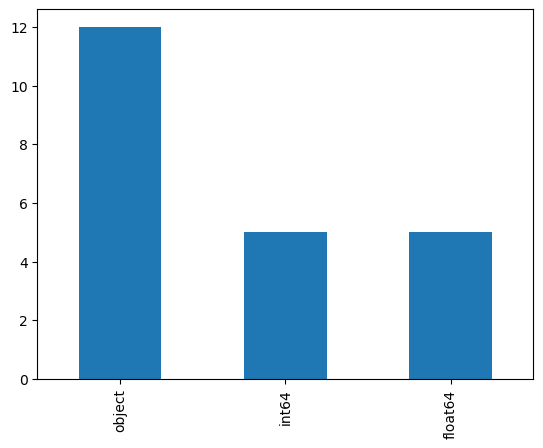

In [7]:
# checking for datatypes count
raw_df.dtypes.value_counts().plot(kind='bar');

- there are 12 objects
- ther are 5 intigers
- there are 5 floats

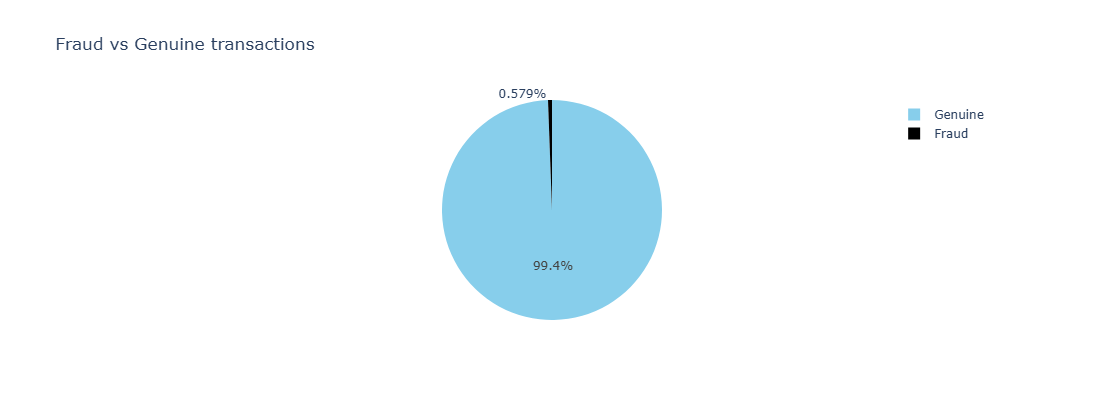

In [8]:
# checvking class imbalance 
labels=["Genuine","Fraud"]

fraud_or_not = raw_df["is_fraud"].value_counts().tolist()
values = [fraud_or_not[0], fraud_or_not[1]]

fig = px.pie(values=raw_df['is_fraud'].value_counts(), names=labels , width=700, height=400, color_discrete_sequence=["skyblue","black"]
             ,title="Fraud vs Genuine transactions")
fig.show()



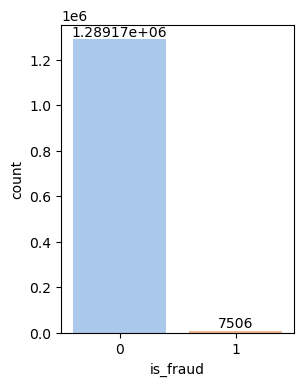

In [9]:
# checking genuine and fraud enteries
plt.figure(figsize=(3,4))
ax = sns.countplot(x='is_fraud',data=raw_df,palette="pastel")
for i in ax.containers:
    ax.bar_label(i,)

In [10]:
print('Genuine:', round(raw_df['is_fraud'].value_counts()[0]/len(raw_df) * 100,2), '% of the dataset')
print('Frauds:', round(raw_df['is_fraud'].value_counts()[1]/len(raw_df) * 100,2), '% of the dataset')


Genuine: 99.42 % of the dataset
Frauds: 0.58 % of the dataset


- the datasets' class is higly imbalanced

In [11]:
# checking for null values
raw_df.isnull().sum().any()

False

- there are no null values in the dataset

In [12]:
# checking for duplicates
raw_df.duplicated().any()

False

- there are no duplicates in the dataset

##### Exploring the 'amt' (amount) 

In [13]:
#looking at distribution of amount
pd.concat(
    [raw_df['amt'].describe(percentiles = [0.5,0.95,0.999]).reset_index().rename(columns={'index': 'Row Type', 'amt':'Overall Amt Distribution'}),
     raw_df.loc[raw_df['is_fraud']==0,['amt']].describe(percentiles = [0.5,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Non-Fraud Amt Distribution'}),
     raw_df.loc[raw_df['is_fraud']==1,['amt']].describe(percentiles = [0.5,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Fraud Amt Distribution'})], axis=1)

,Row Type,Overall Amt Distribution,Non-Fraud Amt Distribution,Fraud Amt Distribution
0,count,1.296675e+06,1.289169e+06,7506.000000
1,mean,7.035104e+01,6.766711e+01,531.320092
2,std,1.603160e+02,1.540080e+02,390.560070
3,min,1.000000e+00,1.000000e+00,1.060000
4,50%,4.752000e+01,4.728000e+01,396.505000
5,95%,1.963100e+02,1.899000e+02,1083.985000
6,99.9%,1.499254e+03,1.503696e+03,1291.038400
7,max,2.894890e+04,2.894890e+04,1376.040000


- The mean of the 'non-fraud amt distribution' at 67 dollars is far less than the 'fraud amt distribution' at 531 dollars.
- This means that in a given set of transaction with balanced number of fraud and non-fraud data points, the mean transaction amount of fraud amt is very high. This implies that the amount lost in a fraud trnasaction is very high.

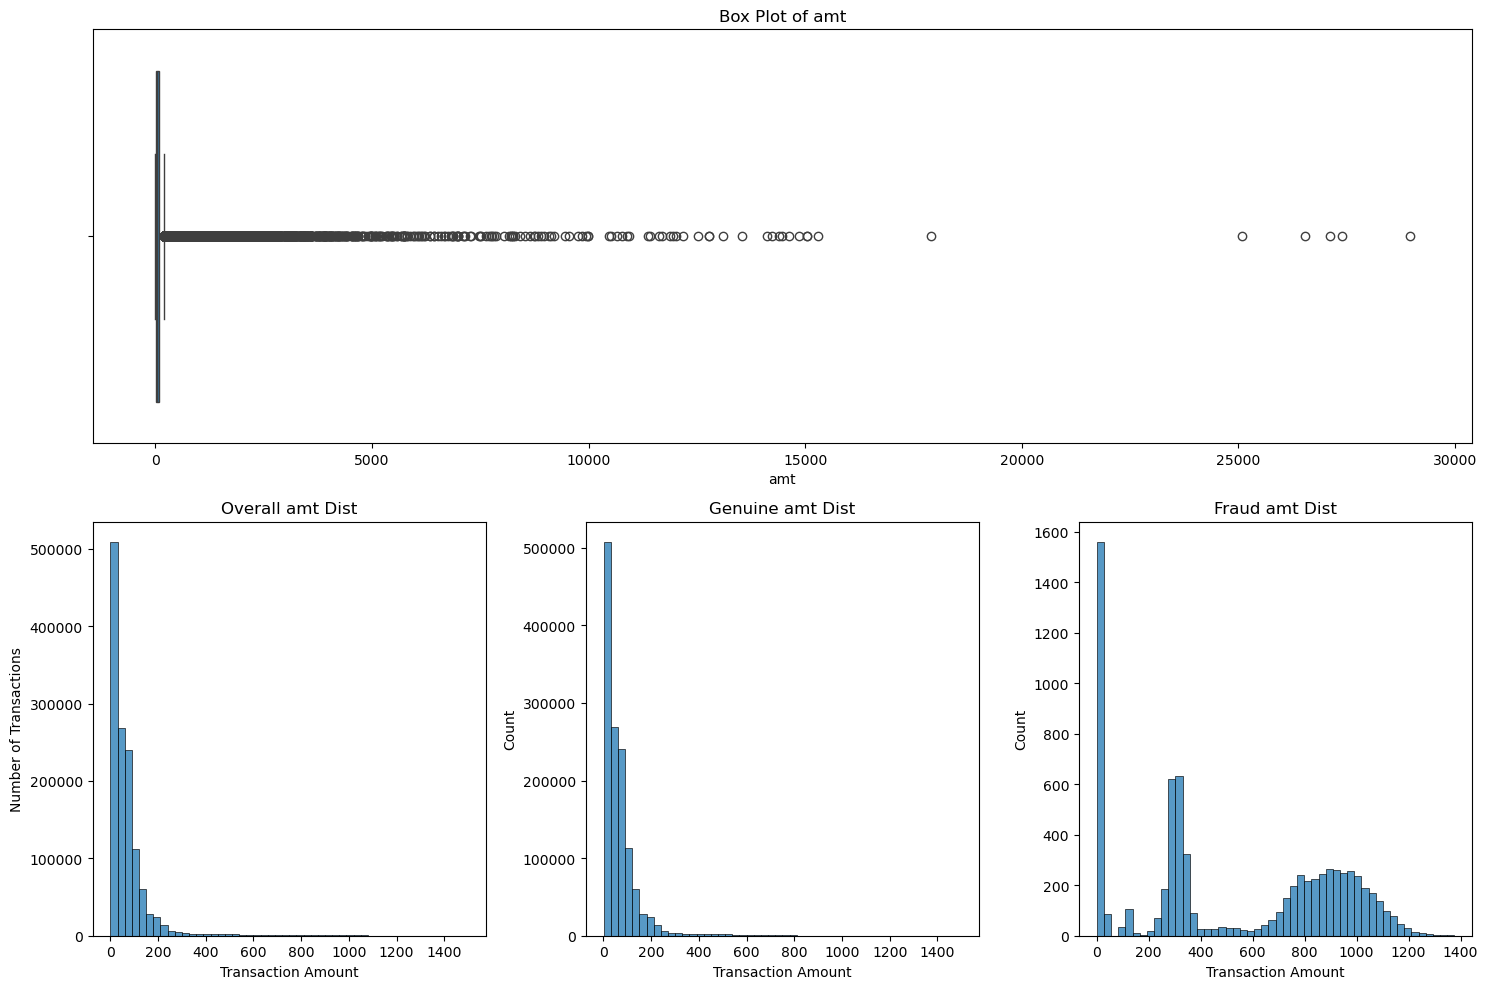

In [14]:
# Create a figure with GridSpec to manage the layout
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

# Plotting the amt feature with a box plot across the entire first row
ax_box = fig.add_subplot(gs[0, :])
sns.boxplot(x=raw_df.amt, ax=ax_box)
ax_box.set_title('Box Plot of amt')

# Plotting the distribution plots in the second row
ax_dist1 = fig.add_subplot(gs[1, 0])
ax_dist2 = fig.add_subplot(gs[1, 1])
ax_dist3 = fig.add_subplot(gs[1, 2])

sns.histplot(raw_df[raw_df.amt <= 1500].amt, bins=50, ax=ax_dist1)
sns.histplot(raw_df[(raw_df.is_fraud == 0) & (raw_df.amt <= 1500)].amt, bins=50, ax=ax_dist2)
sns.histplot(raw_df[(raw_df.is_fraud == 1) & (raw_df.amt <= 1500)].amt, bins=50, ax=ax_dist3)

# Setting titles for the distribution plots
ax_dist1.set_title('Overall amt Dist')
ax_dist2.set_title('Genuine amt Dist')
ax_dist3.set_title('Fraud amt Dist')

# Setting x labels for the distribution plots
ax_dist1.set_xlabel('Transaction Amount')
ax_dist2.set_xlabel('Transaction Amount')
ax_dist3.set_xlabel('Transaction Amount')

# Setting y label for the first distribution plot
ax_dist1.set_ylabel('Number of Transactions')

# Adjust layout to avoid overlap
plt.tight_layout()

- there are many outliers in the amt - hence it is highly skewed
- most highest fraud transactions occur bellow 200 dollars, the second highest around 200 to 400 dolars, there rest around 600 to 1200 dollars 

is_fraud,0,1
min,1.00,1.06
max,28948.90,1376.04
mean,67.67,531.32
median,47.28,396.50


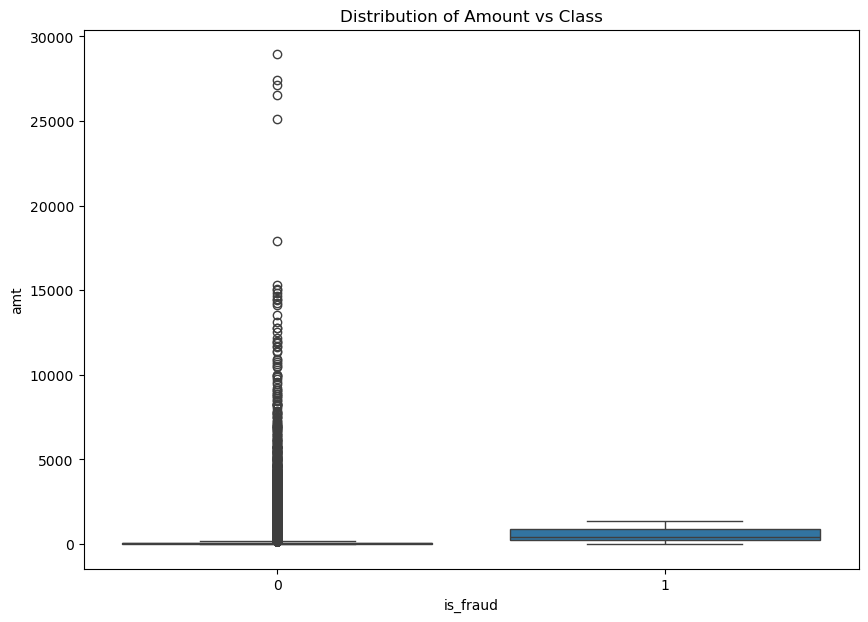

In [15]:
# function for box plot
def plot_box (data, x, y, title , width = 10, height = 7):
  
  plt.figure(figsize = [width,height])
  sns.boxplot(data = data, x = x, y = y)
  plt.title(title);
# function stats by class    
def stats_by_class(variable):
  stat_grid = raw_df.groupby('is_fraud')[variable].agg([np.min,np.max,np.mean,np.median])
  stat_grid = stat_grid.transpose().round(2)
  return stat_grid

plot_box(raw_df,'is_fraud','amt','Distribution of Amount vs Class'); # calling the boxplot function

stats_by_class('amt') # calling the stats_by class function

- fraudulent transactions range from 1.06 to 1375 dollars as shown by the box plot

##### Exploring the 'amt' vs categories

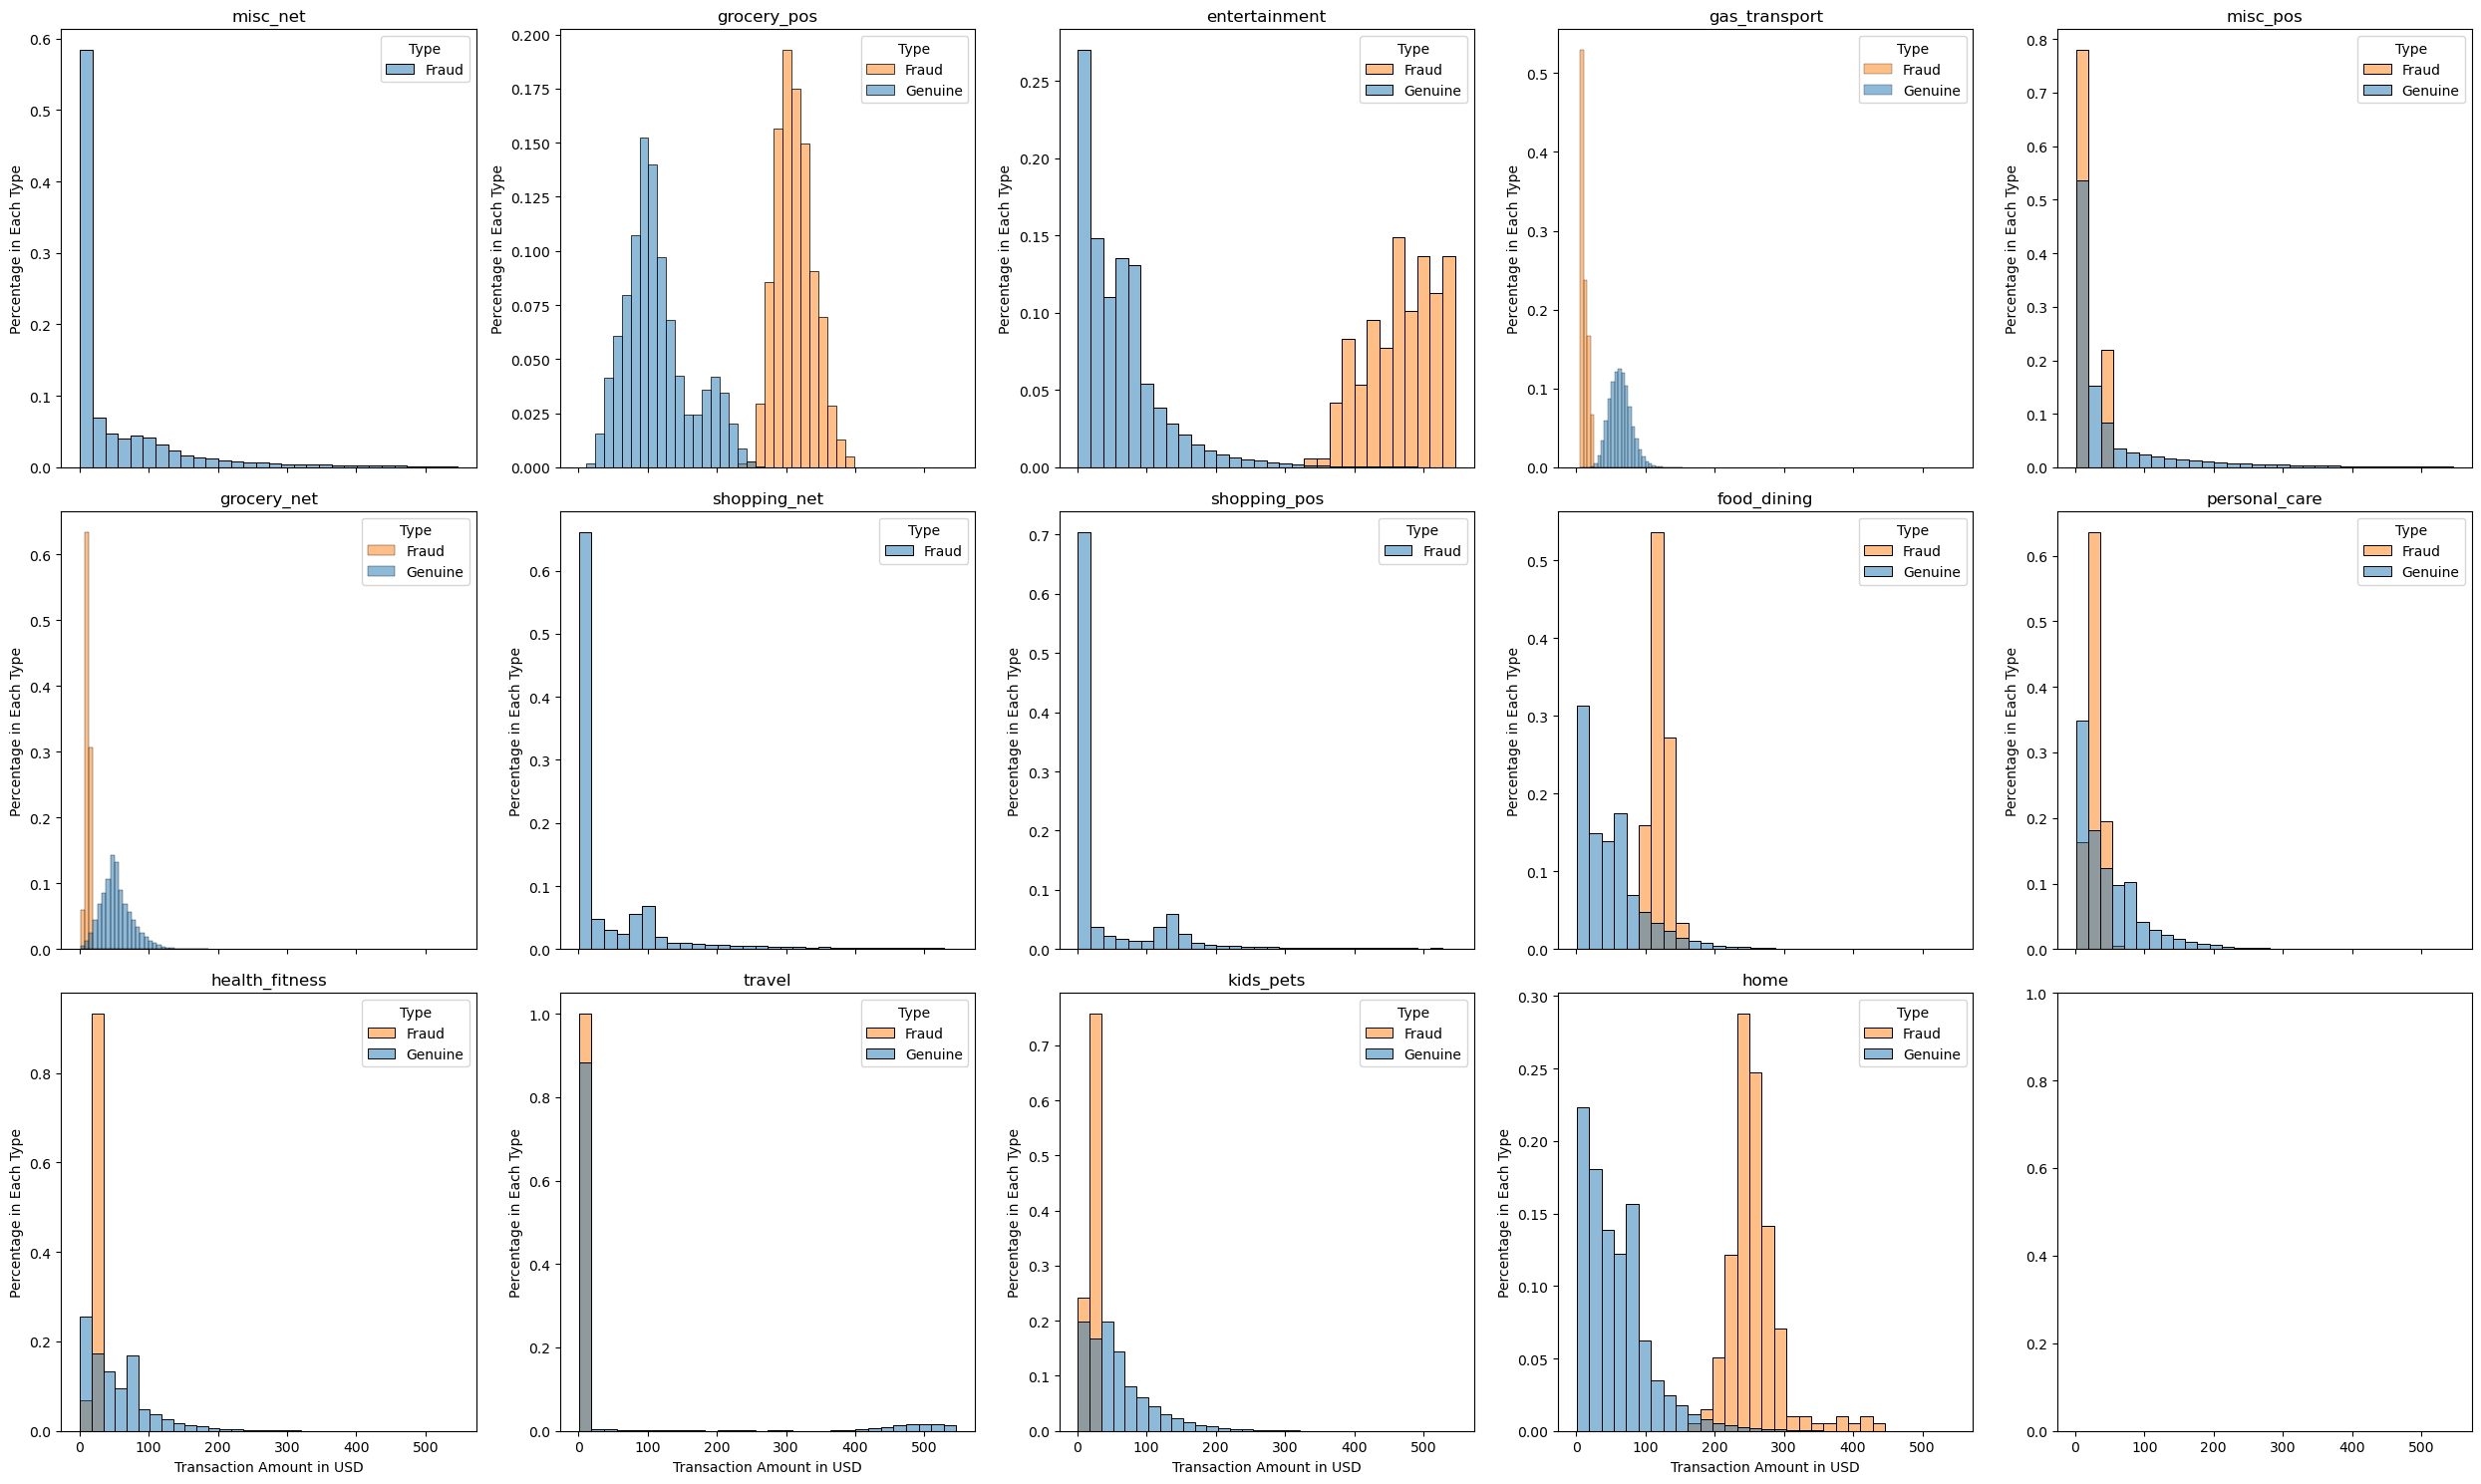

In [16]:
import math
categories = raw_df['category'].unique()

num_plots = len(categories)
num_rows = math.isqrt(num_plots)
num_cols = math.ceil(num_plots / num_rows)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(
    5*num_cols, 5*num_rows), sharex=True)

for i, category in enumerate(categories):

    row = i // num_cols
    col = i % num_cols

    data_category = raw_df[raw_df['category'] == category]

    if num_rows == 1 and num_cols == 1:
        ax = axes
    elif num_rows == 1 or num_cols == 1:
        ax = axes[i]
    else:
        ax = axes[row, col]
    # Higher values of amount is distorting the graph. So we fix it plotting only 0-99% of amount
    sns.histplot(x='amt', data=data_category[data_category['amt'] <= raw_df["amt"].quantile(0.99)],
                 hue='is_fraud', stat='probability',
                 common_norm=False, bins=30, ax=ax)

    ax.set_ylabel('Percentage in Each Type')
    ax.set_xlabel('Transaction Amount in USD')
    ax.set_title(f'{category}')
    ax.legend(title='Type', labels=['Fraud', 'Genuine'])

plt.tight_layout()

- grocery point of sale (grocery_pos), fraudulent transactions occur around 200-400 dollars
- entertainment, fraudulant occur around 300-600 dollars
- home, fraudulent occur around 150-455 dollars
- these categories tend to have higher cost on the bank as the amount tend to be higher

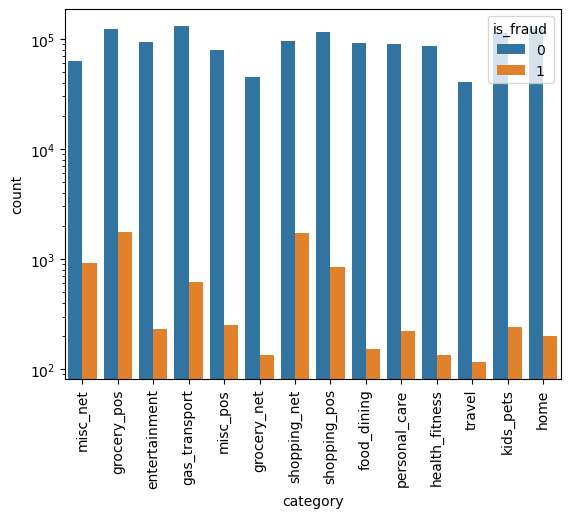

In [17]:
# Plotting the number of fraudulent transactions in different categories
plot = sns.countplot(x='category', hue='is_fraud', data=raw_df)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
# making the count more visible
plt.yscale('log')

In [18]:
# Constructing the category-transaction count distribution
df_category = raw_df[['category', 'trans_num']].groupby(['category']).count().reset_index()
df_category.columns = ['category', 'category_count']

# Creating the category-fraud distribution
df_fraud_category = raw_df[['category', 'trans_num', 'is_fraud']].groupby(['category', 'is_fraud']).count().reset_index()
df_fraud_category.columns = ['category', 'is_fraud', 'Transaction_count']

# Merging the category count with the fraud category data
df_fraud_category = df_fraud_category.merge(df_category[['category', 'category_count']], how='inner', on='category')

# Calculating the transaction percentage
df_fraud_category['Transaction_percentage'] = (df_fraud_category['Transaction_count'] / df_fraud_category['category_count']) * 100

# Viewing the top categories with high fraudulent transaction volumes
top_fraud_categories = df_fraud_category[df_fraud_category['is_fraud'] == 1].sort_values(by=['Transaction_percentage'], ascending=False)

# Display the top fraud categories as a dataframe
top_fraud_categories_df = pd.DataFrame(top_fraud_categories)

# Show the dataframe
top_fraud_categories_df


,category,is_fraud,Transaction_count,category_count,Transaction_percentage
23,shopping_net,1,1713,97543,1.756149
17,misc_net,1,915,63287,1.445795
9,grocery_pos,1,1743,123638,1.409761
25,shopping_pos,1,843,116672,0.722538
5,gas_transport,1,618,131659,0.469394
19,misc_pos,1,250,79655,0.313853
7,grocery_net,1,134,45452,0.294817
27,travel,1,116,40507,0.286370
1,entertainment,1,233,94014,0.247835
21,personal_care,1,220,90758,0.242403


- The table shows the top categories with fraudulent transactions in order, showing the top as the shopping net

##### Gender of the card holder vs class

gender,F,M
genuine percentage,54.77,45.23
fraud percentage,49.76,50.24


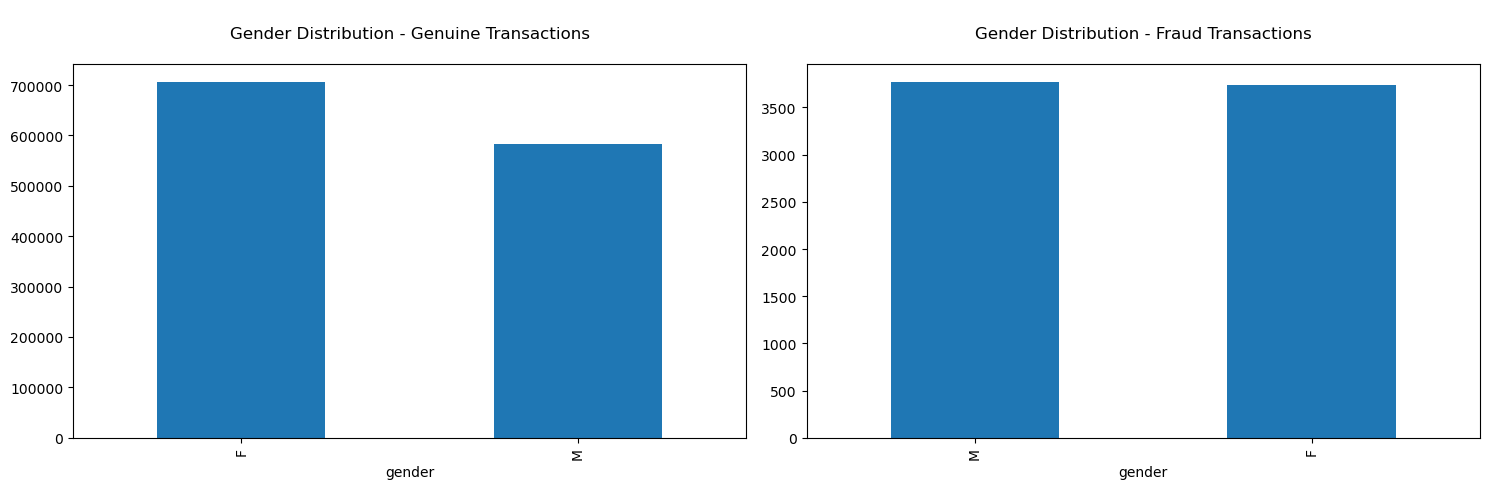

In [19]:
# Create a copy of the raw dataset
Train_trans = raw_df.copy()

# Map the classes 0 & 1 to 'Non_Fraud' and 'Fraud'
Train_trans['class'] = Train_trans['is_fraud'].map({1: 'Fraud', 0: 'Non_Fraud'})

# Create the normal transaction dataset
genuine = Train_trans[Train_trans['is_fraud'] == 0]

# Create the fraud transaction dataset
fraud = Train_trans[Train_trans['is_fraud'] == 1]

# Define the stats_by_var function
def stats_by_var(variable):
    g = (genuine[variable].value_counts(normalize=True) * 100).round(2).rename('genuine percentage')
    f = (fraud[variable].value_counts(normalize=True) * 100).round(2).rename('fraud percentage')
    return pd.concat([g, f], axis=1).transpose()

# Plot gender count vs target class
plt.figure(figsize=[15, 5])

plt.subplot(1, 2, 1)
genuine['gender'].value_counts().plot(kind='bar')
plt.title('\nGender Distribution - Genuine Transactions\n')

plt.subplot(1, 2, 2)
fraud['gender'].value_counts().plot(kind='bar')
plt.title('\nGender Distribution - Fraud Transactions\n')

plt.tight_layout()

# Calling the stats_by_var function for the gender variable
stats_by_var('gender')

- The fraud transaction percentage is almost equaly distributed between male and female

##### Age of card holder vs class

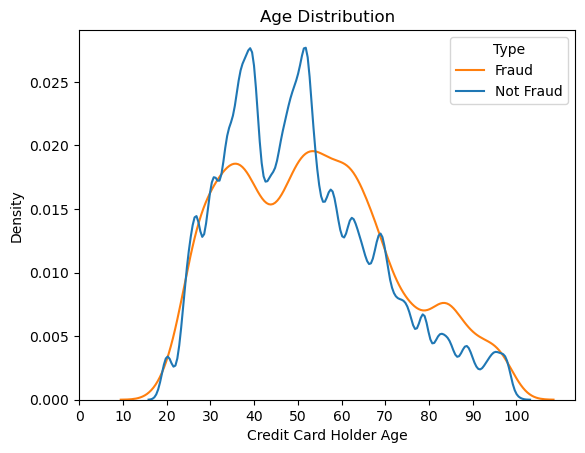

In [20]:
import datetime as dt
raw_df['age'] = dt.date.today().year-pd.to_datetime(raw_df['dob']).dt.year
ax = sns.kdeplot(x='age', data=raw_df, hue='is_fraud', common_norm=False)
ax.set_xlabel('Credit Card Holder Age')
ax.set_ylabel('Density')
plt.xticks(np.arange(0, 110, 10))
plt.title('Age Distribution')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud']);

- In non-fraudulent transactions, there are noticeable peaks around the ages of 35, 40, and 50. Conversely, fraudulent transactions show a more even distribution, with peaks occurring around the age of 35 and between 50 and 55 years old.

In [21]:
# Create age ranges
bins = [0, 30, 45, 60, 75, float('inf')]
labels = ['< 30', '30-45', '46-60', '61-75', '> 75']
raw_df['age_range'] = pd.cut(raw_df['age'], bins=bins, labels=labels, right=False)

# Constructing the age_range-transaction count distribution
df_age = raw_df[['age_range','trans_num']].groupby(['age_range']).count().reset_index()
df_age.columns = ['age_range', 'age_count']

# Creating the age_range-fraud distribution
df_fraud_age = raw_df[['age_range', 'trans_num', 'is_fraud']].groupby(['age_range','is_fraud']).count().reset_index()
df_fraud_age.columns = ['age_range', 'is_fraud', 'Transaction count']

# Merging the distributions
df_fraud_age = df_fraud_age.merge(df_age[['age_range', 'age_count']], how='inner', on='age_range')

# Calculating the transaction percentage
df_fraud_age['Transaction percentage'] = (df_fraud_age['Transaction count'] / df_fraud_age['age_count']) * 100

# Display the result
df_fraud_age

,age_range,is_fraud,Transaction count,age_count,Transaction percentage
0,< 30,0,116139,116901,99.348166
1,< 30,1,762,116901,0.651834
2,30-45,0,413935,415872,99.534232
3,30-45,1,1937,415872,0.465768
4,46-60,0,401146,403191,99.492796
5,46-60,1,2045,403191,0.507204
6,61-75,0,220361,221978,99.271549
7,61-75,1,1617,221978,0.728451
8,> 75,0,137588,138733,99.174674
9,> 75,1,1145,138733,0.825326


- as per the previous distribution graph, this table highlest the exact ranges with the highest fraudulent transactions
- the age range 46-60 is the highest fraudulent transactions followed by the age range 30-45

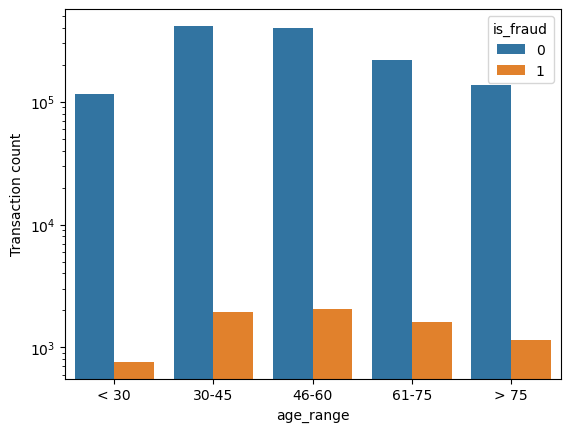

In [22]:
sns.barplot(data=df_fraud_age, y='Transaction count', x='age_range', hue='is_fraud')
# making the count more visible
plt.yscale('log')

In [23]:
raw_df.age_range.unique()

['30-45', '46-60', '61-75', '> 75', '< 30']
Categories (5, object): ['< 30' < '30-45' < '46-60' < '61-75' < '> 75']

#### Fraudulent transactions time in the day by class

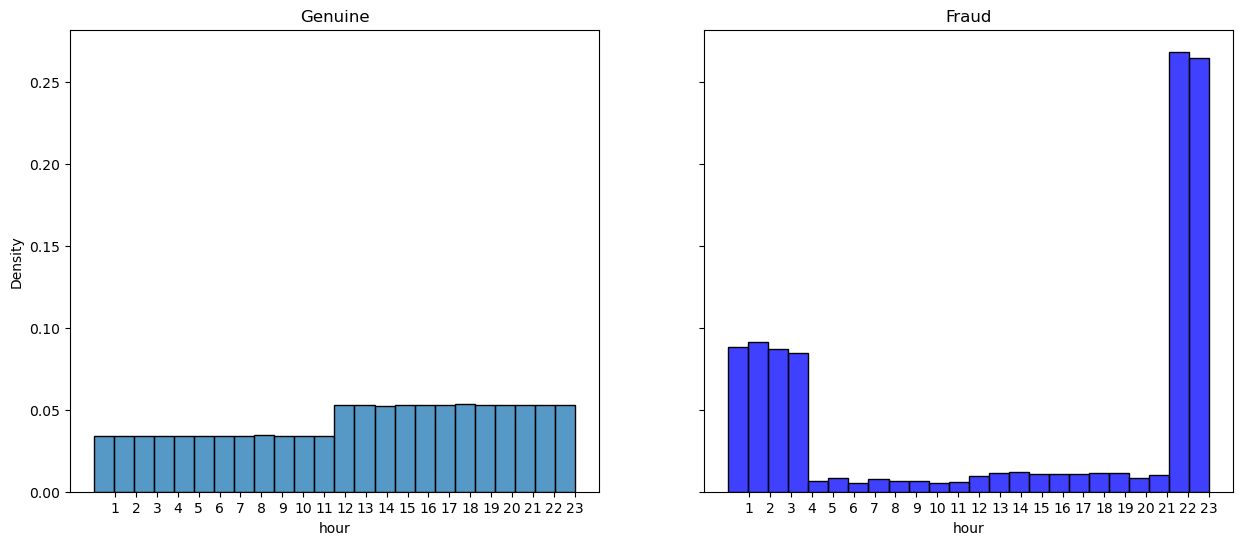

In [24]:
raw_df['hour'] = pd.to_datetime(raw_df['trans_date_trans_time']).dt.hour
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax1 = sns.histplot(x='hour', data=raw_df[raw_df["is_fraud"] == 0],
                   stat="density", bins=24, ax=ax1)
ax2 = sns.histplot(x='hour', data=raw_df[raw_df["is_fraud"] == 1],
                   stat="density", bins=24, ax=ax2, color="blue")
ax1.set_title("Genuine")
ax2.set_title("Fraud")
ax1.set_xticks(np.arange(1, 24))
ax2.set_xticks(np.arange(1, 24));

- fraudulent transactions tend peak from 9pm to 4 am compared to genuine transactions

#### Fraudulent transactions' month distribution by class

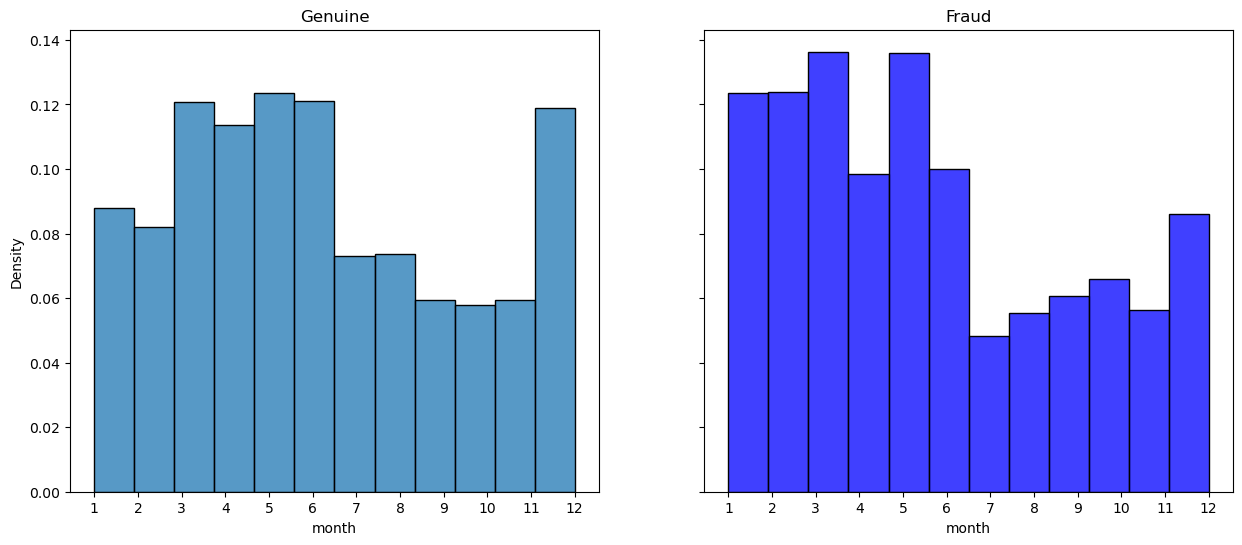

In [25]:
raw_df['month'] = pd.to_datetime(raw_df['trans_date_trans_time']).dt.month
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax1 = sns.histplot(x='month', data=raw_df[raw_df["is_fraud"] == 0],
                   stat="density", bins=12, ax=ax1)
ax2 = sns.histplot(x='month', data=raw_df[raw_df["is_fraud"] == 1],
                   stat="density", bins=12, ax=ax2, color="blue")
ax1.set_title("Genuine")
ax2.set_title("Fraud")
ax1.set_xticks(np.arange(1, 13))
ax2.set_xticks(np.arange(1, 13));

- there is no significant difference between genuine and fraudulent transactions' months by class

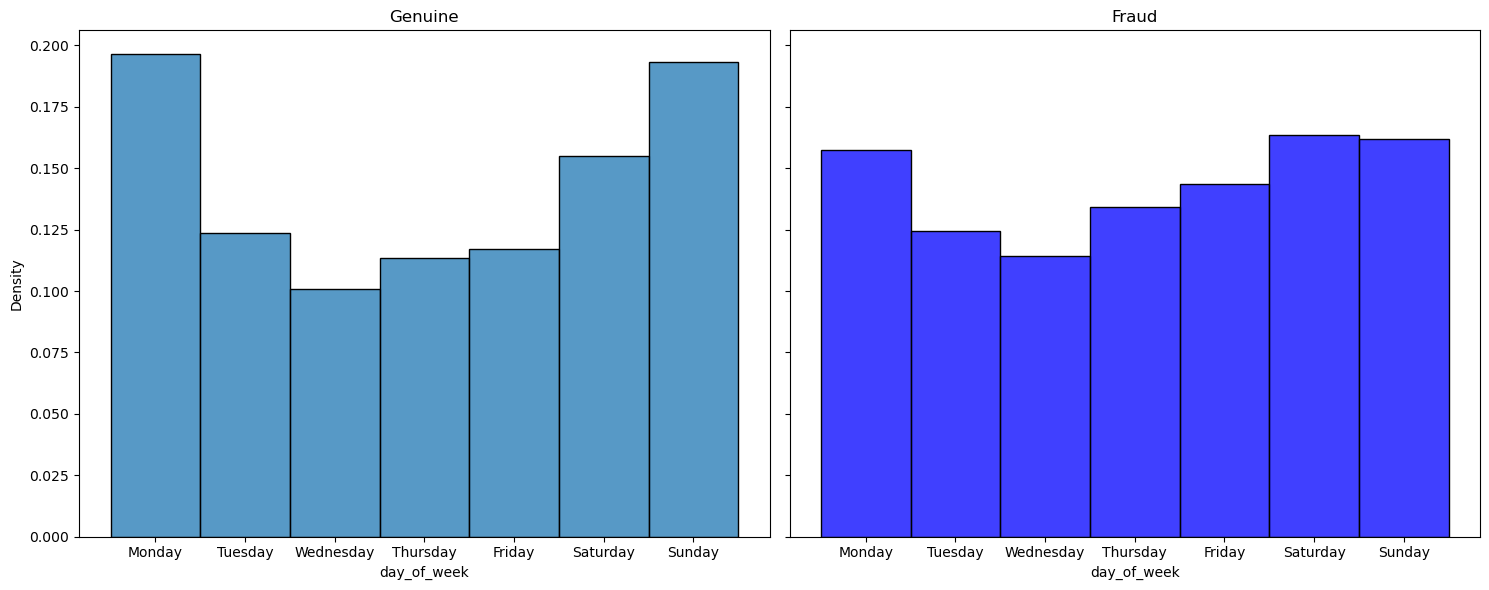

In [26]:
# Convert 'trans_date_trans_time' to datetime 
raw_df['trans_date_trans_time'] = pd.to_datetime(raw_df['trans_date_trans_time'])

# Create a categorical type for the days of the week with the desired order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
raw_df['day_of_week'] = pd.Categorical(raw_df['trans_date_trans_time'].dt.day_name(), categories=day_order, ordered=True)

# Plotting day of the week distribution for genuine and fraudulent transactions
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.histplot(x=raw_df[raw_df["is_fraud"] == 0]['day_of_week'],
             stat="density", ax=ax1)
sns.histplot(x=raw_df[raw_df["is_fraud"] == 1]['day_of_week'],
             stat="density", ax=ax2, color="blue")

ax1.set_title("Genuine")
ax2.set_title("Fraud")

plt.tight_layout()
plt.show()

- Saturday, sunday and Monday are the top days to have fraudulent transactions

##### State vs class

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50],
 [Text(0, 0, 'NY'),
  Text(1, 0, 'TX'),
  Text(2, 0, 'PA'),
  Text(3, 0, 'CA'),
  Text(4, 0, 'OH'),
  Text(5, 0, 'FL'),
  Text(6, 0, 'IL'),
  Text(7, 0, 'MI'),
  Text(8, 0, 'AL'),
  Text(9, 0, 'MN'),
  Text(10, 0, 'VA'),
  Text(11, 0, 'SC'),
  Text(12, 0, 'MO'),
  Text(13, 0, 'NE'),
  Text(14, 0, 'WI'),
  Text(15, 0, 'AR'),
  Text(16, 0, 'MD'),
  Text(17, 0, 'KS'),
  Text(18, 0, 'KY'),
  Text(19, 0, 'OR'),
  Text(20, 0, 'NC'),
  Text(21, 0, 'GA'),
  Text(22, 0, 'WV'),
  Text(23, 0, 'OK'),
  Text(24, 0, 'IA'),
  Text(25, 0, 'IN'),
  Text(26, 0, 'TN'),
  Text(27, 0, 'ME'),
  Text(28, 0, 'NJ'),
  Text(29, 0, 'MS'),
  Text(30, 0, 'CO'),
  Text(31, 0, 'WY'),
  Text(32, 0, 'WA'),
  Text(33, 0, 'LA'),

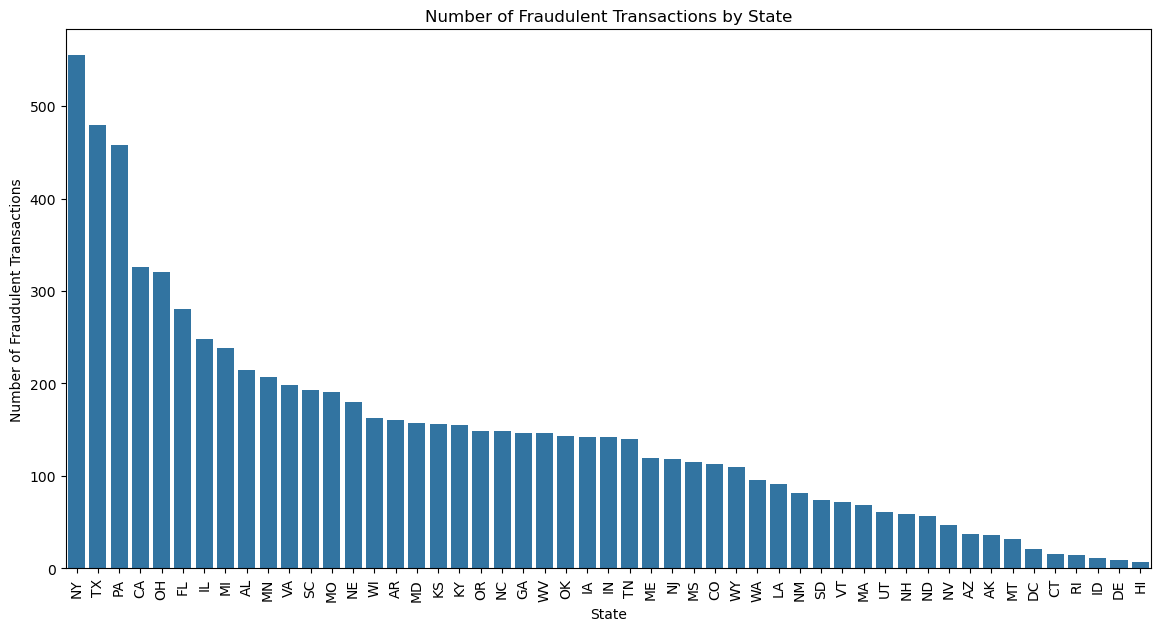

In [27]:
# Calculate the number of fraudulent transactions by state
fraud_by_state = raw_df[raw_df['is_fraud'] == 1]['state'].value_counts()

# Plot the fraud trends by state
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_state.index, y=fraud_by_state.values)
plt.title('Number of Fraudulent Transactions by State')
plt.xlabel('State')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)

- there highest 3 states with fraudulent transactions are NY, TX and PA

In [28]:
#constructing the state-transaction count distribution
df_state = raw_df[['state','trans_num']].groupby(['state']).count().reset_index()
df_state.columns = ['state', 'state_count']

#creating the state-fraud distribution
df_fraud_state = raw_df[['state', 'trans_num', 'is_fraud']].groupby(['state','is_fraud']).count().reset_index()
df_fraud_state.columns = ['state', 'is_fraud', 'Transaction count']

df_fraud_state = df_fraud_state.merge(df_state[['state', 'state_count']], how='inner', on='state')

df_fraud_state['Transaction percentage'] = (df_fraud_state['Transaction count']/df_fraud_state['state_count'])*100

#viewing the top 20 states with high fraudulent transactions
df_fraud_state[df_fraud_state['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,state,is_fraud,Transaction count,state_count,Transaction percentage
16,DE,1,9,9,100.000000
78,RI,1,15,550,2.727273
1,AK,1,36,2120,1.698113
66,NV,1,47,5607,0.838238
11,CO,1,113,13880,0.814121
74,OR,1,149,18597,0.801204
84,TN,1,140,17554,0.797539
58,NE,1,180,24168,0.744786
42,ME,1,119,16505,0.720994
60,NH,1,59,8278,0.712733


- DE state has all it's transactions as fraudulent

##### Cities vs fruad

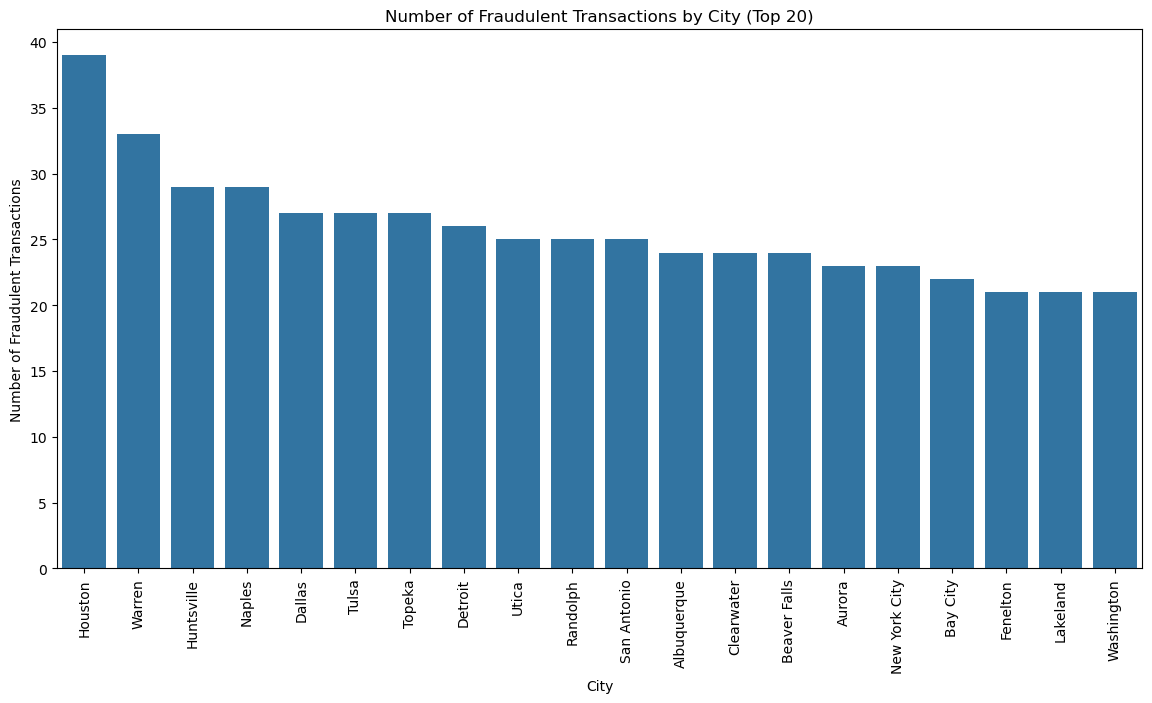

In [29]:
# Calculate the number of fraudulent transactions by city
fraud_by_city = raw_df[raw_df['is_fraud'] == 1]['city'].value_counts().head(20)  # Top 20 cities with most frauds

# Plot the fraud trends by city
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_city.index, y=fraud_by_city.values)
plt.title('Number of Fraudulent Transactions by City (Top 20)')
plt.xlabel('City')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)
plt.show()

- Houston, Warrenm, Huntsville and Naples are the top 4 cities with highest fraudulent transactions 

In [30]:
#constructing the city-transaction count distribution
df_city = raw_df[['city','trans_num']].groupby(['city']).count().reset_index()
df_city.columns = ['city', 'city_count']

#creating the city-fraud distribution
df_fraud_city = raw_df[['city', 'trans_num', 'is_fraud']].groupby(['city','is_fraud']).count().reset_index()
df_fraud_city.columns = ['city', 'is_fraud', 'Transaction count']

df_fraud_city = df_fraud_city.merge(df_city[['city', 'city_count']], how='inner', on='city')

df_fraud_city['Transaction percentage'] = (df_fraud_city['Transaction count']/df_fraud_city['city_count'])*100

#viewing the top 20 cities with high fraudulent transaction volumes
df_fraud_city[df_fraud_city['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,city,is_fraud,Transaction count,city_count,Transaction percentage
401,East China,1,9,9,100.0
1441,Walkertown,1,11,11,100.0
476,Freeport,1,9,9,100.0
483,Gaines,1,8,8,100.0
511,Granbury,1,12,12,100.0
1060,Orange Park,1,10,10,100.0
531,Greenport,1,10,10,100.0
101,Beacon,1,11,11,100.0
1444,Wappapello,1,8,8,100.0
989,Nicholson,1,9,9,100.0


- the table above shows the top 20 cities where all the transactions are fraudulent

##### Job vs class

Text(0, 0.5, 'Job')

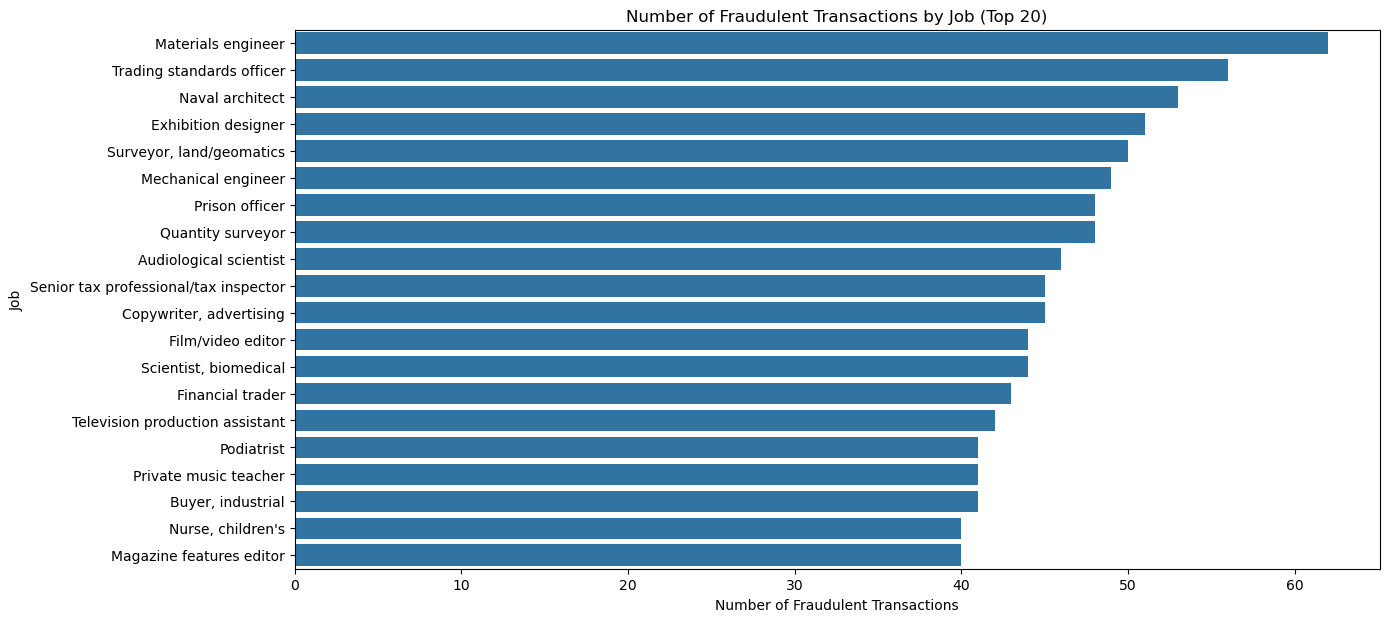

In [31]:
# Calculate the number of fraudulent transactions by job
fraud_by_job = raw_df[raw_df['is_fraud'] == 1]['job'].value_counts().head(20)  # Top 20 jobs with most frauds

# Plot the fraud trends by job
plt.figure(figsize=(14, 7))
sns.barplot(x=fraud_by_job.values, y=fraud_by_job.index)
plt.title('Number of Fraudulent Transactions by Job (Top 20)')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Job')

- top 3 jobs that have fraudulent transactions are Materials engineer, trading standards officers, and navel architect

In [32]:
#constructing the job-transaction count distribution
df_job = raw_df[['job','trans_num']].groupby(['job']).count().reset_index()
df_job.columns = ['job', 'job_count']

#creating the job-fraud distribution
df_fraud_job = raw_df[['job', 'trans_num', 'is_fraud']].groupby(['job','is_fraud']).count().reset_index()
df_fraud_job.columns = ['job', 'is_fraud', 'Transaction count']

df_fraud_job = df_fraud_job.merge(df_job[['job', 'job_count']], how='inner', on='job')

df_fraud_job['Transaction percentage'] = (df_fraud_job['Transaction count']/df_fraud_job['job_count'])*100

#viewing the top 20 jobs with high fraudulent transaction volumes
df_fraud_job[df_fraud_job['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,job,is_fraud,Transaction count,job_count,Transaction percentage
64,Armed forces technical officer,1,8,8,100.000000
318,"Engineer, site",1,12,12,100.000000
453,Information officer,1,8,8,100.000000
493,Legal secretary,1,12,12,100.000000
450,Industrial buyer,1,10,10,100.000000
111,Careers adviser,1,15,15,100.000000
421,Homeopath,1,11,11,100.000000
94,Broadcast journalist,1,9,9,100.000000
619,Personnel officer,1,12,12,100.000000
374,Forest/woodland manager,1,9,9,100.000000


- the table shows the 19 jobs that have all their transactions as fraudulent - comparing to real life, it seems unrealistic

##### Merchant vs class

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'fraud_Rau and Sons'),
  Text(1, 0, 'fraud_Cormier LLC'),
  Text(2, 0, 'fraud_Kozey-Boehm'),
  Text(3, 0, 'fraud_Doyle Ltd'),
  Text(4, 0, 'fraud_Vandervort-Funk'),
  Text(5, 0, 'fraud_Kilback LLC'),
  Text(6, 0, 'fraud_Padberg-Welch'),
  Text(7, 0, 'fraud_Kuhn LLC'),
  Text(8, 0, 'fraud_Terry-Huel'),
  Text(9, 0, 'fraud_Koepp-Witting'),
  Text(10, 0, 'fraud_Goyette Inc'),
  Text(11, 0, 'fraud_Jast Ltd'),
  Text(12, 0, 'fraud_Kiehn-Emmerich'),
  Text(13, 0, 'fraud_Kerluke-Abshire'),
  Text(14, 0, 'fraud_Schmeler, Bashirian and Price'),
  Text(15, 0, 'fraud_McDermott-Weimann'),
  Text(16, 0, 'fraud_Hudson-Ratke'),
  Text(17, 0, 'fraud_Gleason-Macejkovic'),
  Text(18, 0, 'fraud_Moen, Reinger and Murphy'),
  Text(19, 0, 'fraud_Boyer PLC')])

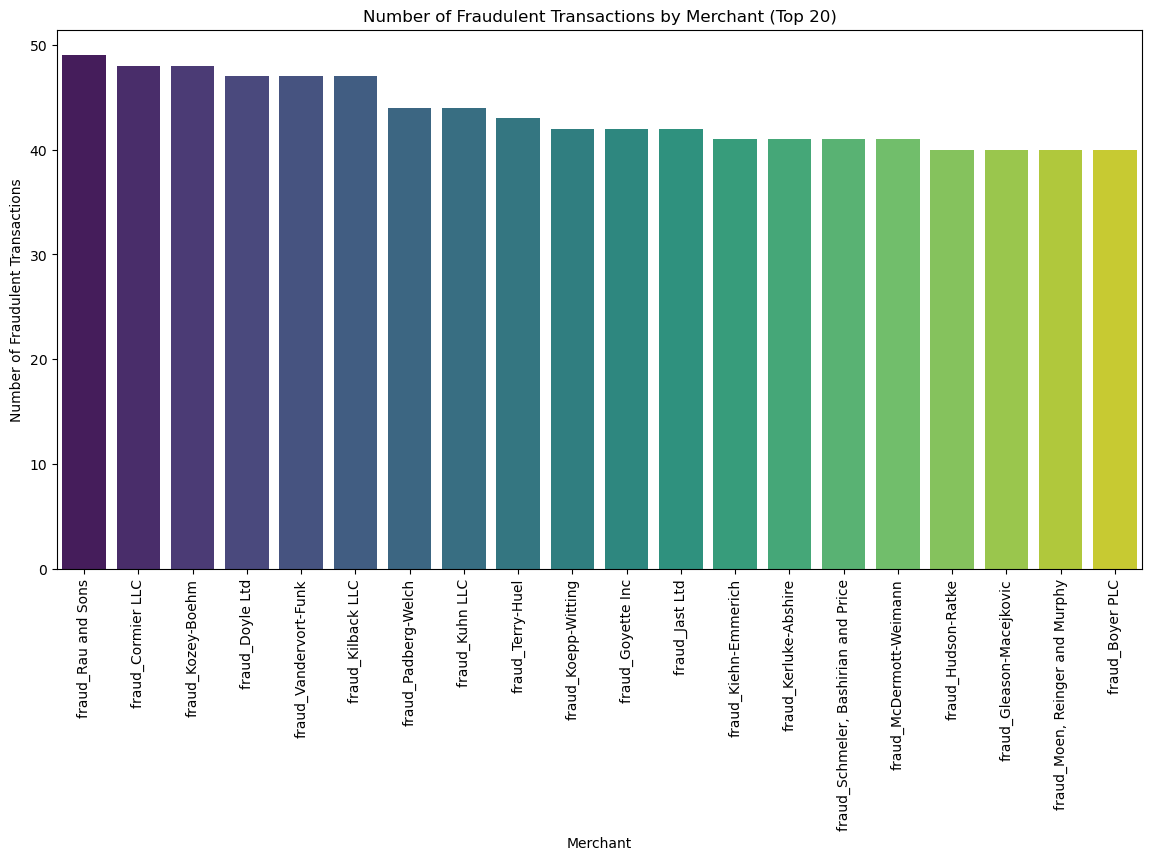

In [33]:
# Calculate the number of fraudulent transactions by merchant
fraud_by_merchant = raw_df[raw_df['is_fraud'] == 1]['merchant'].value_counts()

# Get the top 20 merchants with the highest number of fraudulent transactions
top_20_fraud_by_merchant = fraud_by_merchant.head(20)

# Plot the fraud distribution by merchant
plt.figure(figsize=(14, 7))
sns.barplot(x=top_20_fraud_by_merchant.index, y=top_20_fraud_by_merchant.values, palette="viridis")
plt.title('Number of Fraudulent Transactions by Merchant (Top 20)')
plt.xlabel('Merchant')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)

In [34]:
#constructing the merchant-transaction count distribution
df_merchant = raw_df[['merchant','trans_num']].groupby(['merchant']).count().reset_index()
df_merchant.columns = ['merchant', 'merchant_count']

#creating the merchant-fraud distribution
df_fraud_merchant = raw_df[['merchant', 'trans_num', 'is_fraud']].groupby(['merchant','is_fraud']).count().reset_index()
df_fraud_merchant.columns = ['merchant', 'is_fraud', 'Transaction count']

df_fraud_merchant = df_fraud_merchant.merge(df_merchant[['merchant', 'merchant_count']], how='inner', on='merchant')

df_fraud_merchant['Transaction percentage'] = (df_fraud_merchant['Transaction count']/df_fraud_merchant['merchant_count'])*100

#viewing the top 20 merchant with high fraudulent transaction volumes
df_fraud_merchant[df_fraud_merchant['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,merchant,is_fraud,Transaction count,merchant_count,Transaction percentage
672,fraud_Kozey-Boehm,1,48,1866,2.572347
489,"fraud_Herman, Treutel and Dickens",1,33,1300,2.538462
606,fraud_Kerluke-Abshire,1,41,1838,2.230686
159,fraud_Brown PLC,1,26,1176,2.210884
400,fraud_Goyette Inc,1,42,1943,2.161606
1220,fraud_Terry-Huel,1,43,1996,2.154309
562,fraud_Jast Ltd,1,42,1953,2.150538
1100,"fraud_Schmeler, Bashirian and Price",1,41,1968,2.083333
145,fraud_Boyer-Reichert,1,38,1908,1.991614
742,"fraud_Langworth, Boehm and Gulgowski",1,39,1969,1.980701


- this table shows the highest fraudulent transaction percentages compared to total transactions for each merchant
- highest is Kozey-Boehm with 2.57 % of it's total transactions as fraudulent

#### Features correlation matrix 

<Axes: >

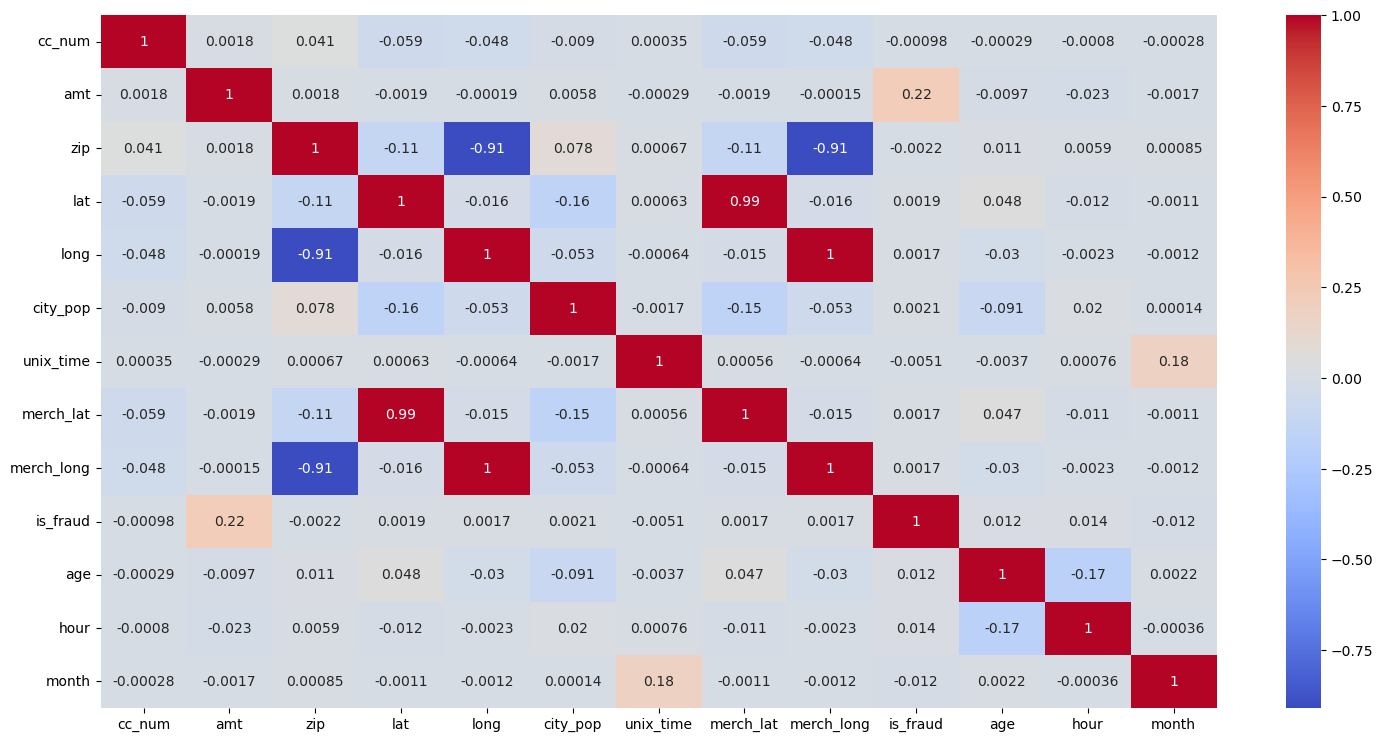

In [35]:
# Specify the numeric_only parameter 
corr_matrix = raw_df.corr(numeric_only=True)

# Create a heatmap for the correlation matrix
fig = plt.figure(figsize=(18, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)

- amount shows the highest correlation to the target


# 3. Feature Engineering

In [36]:
# loading the raw dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

##### Extract features from trans_date_trans_time

In [37]:
# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour column
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

# Extract the transaction month column
df['trans_month'] = df['trans_date_trans_time'].dt.month 

# Extract the day of the week
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

In [38]:
# Verify the new columns
print(df[['trans_date_trans_time', 'trans_hour', 'trans_month', 'trans_dayofweek']].head())

  trans_date_trans_time  trans_hour  trans_month trans_dayofweek
0   2019-01-01 00:00:18           0            1         Tuesday
1   2019-01-01 00:00:44           0            1         Tuesday
2   2019-01-01 00:00:51           0            1         Tuesday
3   2019-01-01 00:01:16           0            1         Tuesday
4   2019-01-01 00:03:06           0            1         Tuesday


In [39]:
df['trans_hour'].unique() # printing the unique values in the extracted series

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [40]:
df['trans_month'].unique() # printing the unique values in the extracted series

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [41]:
df['trans_dayofweek'].unique() # printing the unique values in the extracted series

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

##### Extract features from unix_time

In [42]:
# Convert unix_time to datetime
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')

# Sort by user (cc_num) and transaction time
df = df.sort_values(by=['cc_num', 'transaction_time'])

# Calculate the previous transaction time using shift
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)

# Fill null values with current unix_time - 86400 (one day in seconds)
df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400, inplace=True)

# Calculate the time delta in minutes between the previous and current transaction
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60
df['timedelta_last_trans'].head()

1017    1440.0
2724    1197.0
2726       2.0
2882     230.0
2907      32.0
Name: timedelta_last_trans, dtype: float64

In [43]:
df.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
trans_hour               False
trans_month              False
trans_dayofweek          False
transaction_time         False
unix_time_prev_trans     False
timedelta_last_trans     False
dtype: bool

##### Extract features from dob

In [44]:
# Convert columns to datetime
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Calculate age at the time of transaction
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Display the result
print(df['cust_age'].head())

1017    32
2724    32
2726    32
2882    32
2907    32
Name: cust_age, dtype: int64


##### Extracting features from customer lat/long and merchant lat/long

In [45]:
# Define the Haversine function
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

# Create a new DataFrame to perform calculations
df_calc = pd.DataFrame(df)

# Sort by user (cc_num) to ensure correct order of transactions
df_calc = df_calc.sort_values(by=['cc_num'])

# Shift latitude and longitude of the previous merchant to get the previous transaction's coordinates
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)

# Fill null values with the current merchant's coordinates
df_calc['prev_merch_lat'].fillna(df_calc['merch_lat'], inplace=True)
df_calc['prev_merch_long'].fillna(df_calc['merch_long'], inplace=True)

# Calculate the distance using the Haversine formula
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1)

df_calc['distance_from_prev_merch'].head()

1017      17092.507729
847919    16948.058741
847911    16927.249111
847888    16814.906255
844274    16812.276483
Name: distance_from_prev_merch, dtype: float64

In [46]:
# Add the calculated distances back to the original DataFrame
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']
df['distance_from_prev_merch'].head()

1017    17092.507729
2724    16810.034615
2726    16869.192226
2882    16714.557097
2907    16988.374462
Name: distance_from_prev_merch, dtype: float64

In [47]:
list(df.columns)

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'trans_hour',
 'trans_month',
 'trans_dayofweek',
 'transaction_time',
 'unix_time_prev_trans',
 'timedelta_last_trans',
 'cust_age',
 'distance_from_prev_merch']

In [48]:
# Listing the redundant features to be dropped from the df
drop_cols = ['Unnamed: 0','street','merchant','zip','first','last','trans_num','trans_date_trans_time','transaction_time','cc_num','unix_time','unix_time_prev_trans','lat',
              'long','merch_lat','merch_long','dob','city']

In [49]:
df.drop(drop_cols, axis = 1, inplace = True)
df.reset_index(drop=True, inplace = True)
list(df.columns) # remaining list of columns after removing redundant features

['category',
 'amt',
 'gender',
 'state',
 'city_pop',
 'job',
 'is_fraud',
 'trans_hour',
 'trans_month',
 'trans_dayofweek',
 'timedelta_last_trans',
 'cust_age',
 'distance_from_prev_merch']

# 4. Splitting the train datasets 70% train, 30 % validation

- The aim to do splitting before any econding and normalization is to prevent data leakage from the target into the train
- to avoid over fitting and improve the model's robustness

In [50]:
# splitting the train datasets into X and y
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# importing splitting module from sklearn
from sklearn.model_selection import train_test_split
# splitting the X and y into train and validate, using stratify split to ensure equal ratio of fraud and genuine 
# between the train and validate as the datasets is highly imbalanced
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size = 0.3, random_state = 42)
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(907672, 12)
(389003, 12)
(907672,)
(389003,)


In [51]:
# Check if the variables are numpy arrays
print(isinstance(X_train, np.ndarray))  # True if X_train is a numpy array
print(isinstance(X_val, np.ndarray))    # True if X_val is a numpy array
print(isinstance(y_train, np.ndarray))  # True if y_train is a numpy array
print(isinstance(y_val, np.ndarray))    # True if y_val is a numpy array

False
False
False
False


In [52]:
# Save DataFrames to CSV
#X_train.to_csv('X_train.csv', index=False)
#X_val.to_csv('X_val.csv', index=False)
#y_train.to_csv('y_train.csv', index=False)
#y_val.to_csv('y_val.csv', index=False)

# 5. Features encoding, handling outliers and normalisation on train dataset

##### capping outliers

In [53]:
# installing features enngine
!pip install feature_engine

In [54]:
# Selecting numerical columns
num_cols = X_train.select_dtypes(include = np.number).columns

num_cols

Index(['amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans',
       'cust_age', 'distance_from_prev_merch'],
      dtype='object')

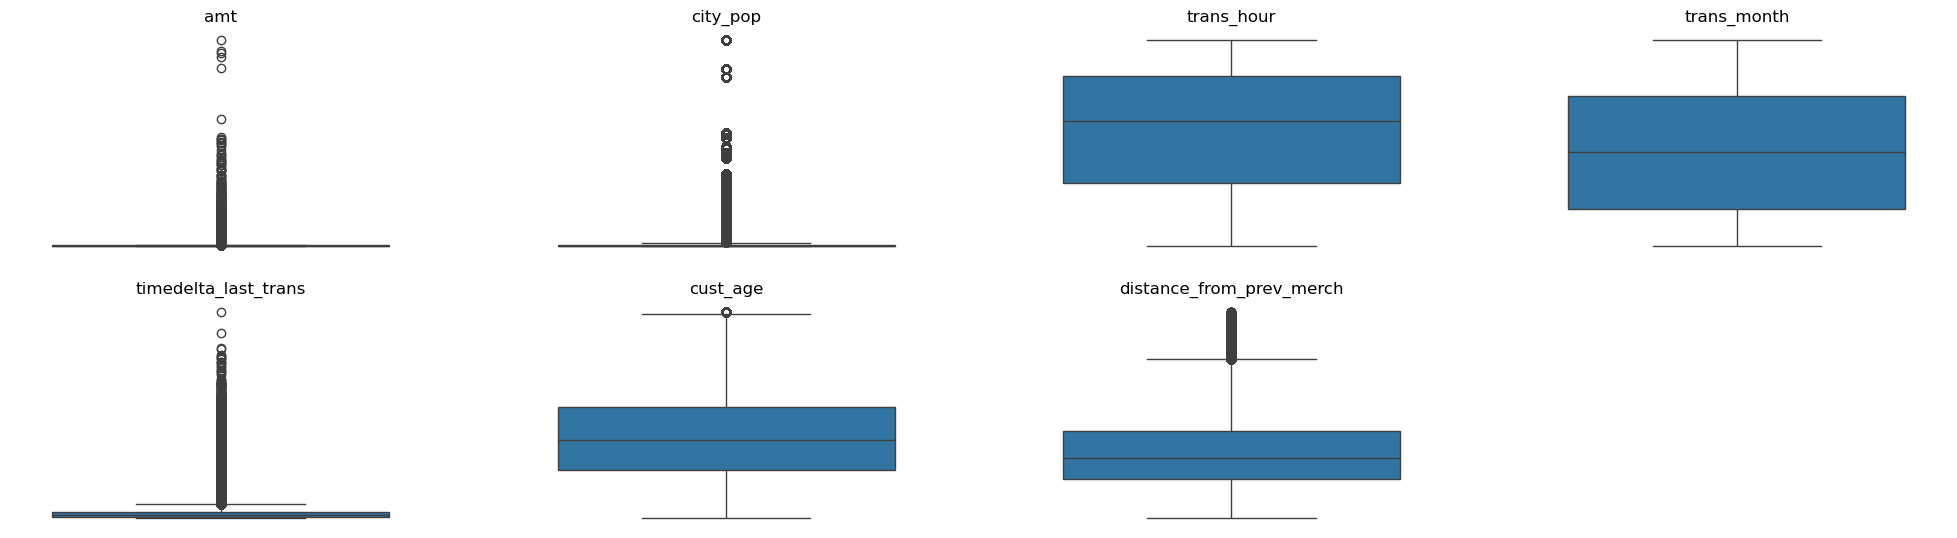

In [55]:
# checking for outliers
plt.figure(figsize = [25,10])

for ind,col_name in enumerate(num_cols):
  plot_var = df[col_name]
  plt.subplot(3,4,ind+1)
  sns.boxplot(plot_var)
  plt.title(col_name)
  plt.axis(False)

- amt, city pop, timedelta_lasttrans and distance_from_prev_merch has some outliers

In [56]:
# importing Winsorizer to cap the outlers using IQR
from feature_engine.outliers import Winsorizer
# outliers to be capped
outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch','cust_age'] 
# choosing the IQR method with fold = 1.5 time of IQR
capper_iqr = Winsorizer(capping_method = 'iqr',tail = 'both', fold = 1.5, variables = outliers) 

In [57]:
print(X_train.shape)
print(X_val.shape)

(907672, 12)
(389003, 12)


In [58]:
# capping outliers in X_train
capper_iqr.fit(X_train)
capper_iqr.fit(X_val)
X_train = capper_iqr.transform(X_train) 
# capping outliers from 
X_test = capper_iqr.transform(X_val)

In [59]:
print(X_train.shape)
print(X_val.shape)

(907672, 12)
(389003, 12)


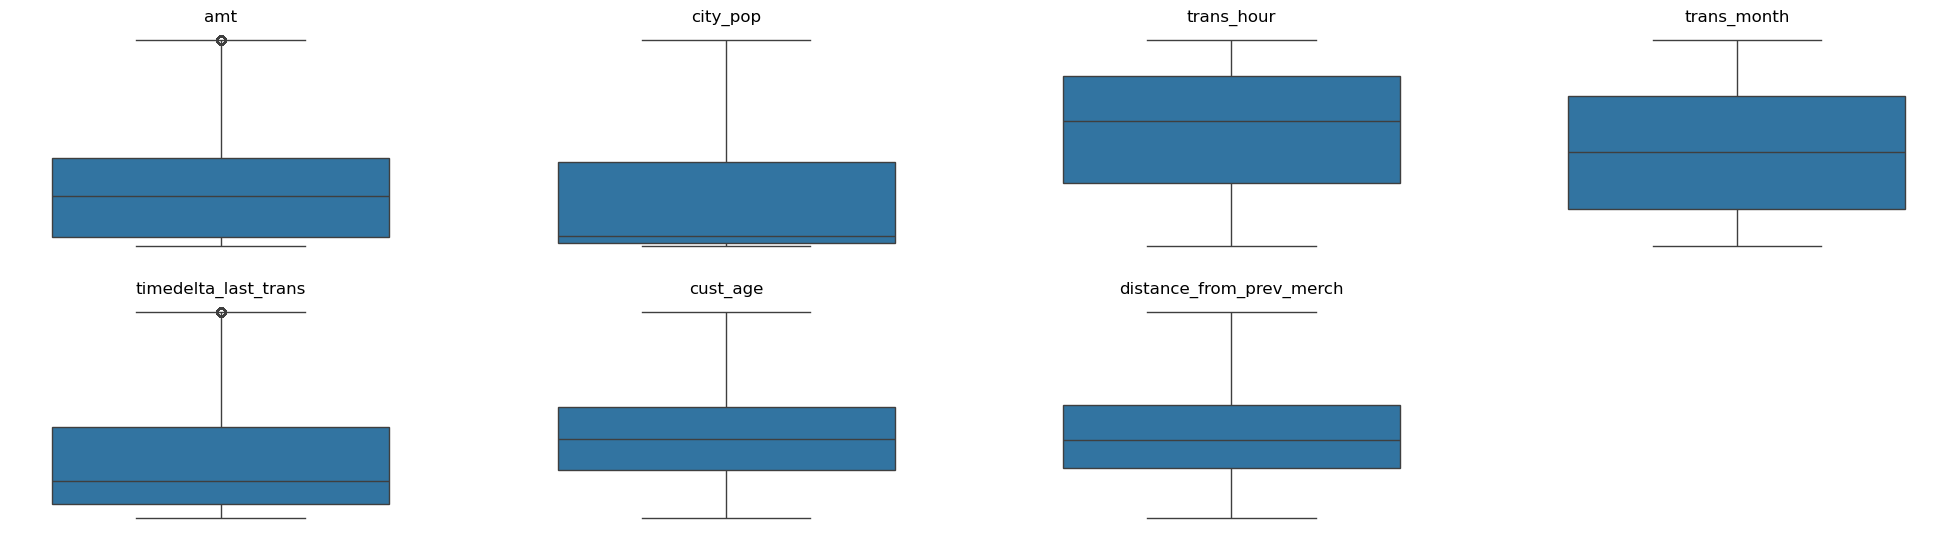

In [60]:
# checking for outliers
plt.figure(figsize = [25,10])

for ind,col_name in enumerate(num_cols):
  plot_var = X_train[col_name]
  plt.subplot(3,4,ind+1)
  sns.boxplot(plot_var)
  plt.title(col_name)
  plt.axis(False)

- outliers have been capped

##### Categorical encoding

In [61]:
# installing category encoders
!pip install category_encoders


In [62]:
# importing categorical encoding
import category_encoders as ce
# importing job lib to save the encoder to be used to encode the unseen data later
import joblib

# Function to apply WOE encoding and save encoders
def apply_woe_and_save_encoders(X_train, X_val, y_train, columns, encoder_filename):
    woe_encoders = []
    for col in columns:
        woe = ce.WOEEncoder(cols=[col])
        
        # Fit the encoder on the training data
        X_train_transformed = woe.fit_transform(X_train[[col]], y_train)
        
        # Transform the validation data
        X_val_transformed = woe.transform(X_val[[col]])
        
        # Add the transformed columns to the original DataFrames
        new_col_name = f"{col}_WOE"
        X_train[new_col_name] = X_train_transformed[col]
        X_val[new_col_name] = X_val_transformed[col]
        
        # Store the encoder
        woe_encoders.append(woe)

    # Save the list of encoders
    joblib.dump(woe_encoders, encoder_filename)
    
    return X_train, X_val

# Categorical columns to encode
columns_to_encode = ['state', 'job', 'category', 'trans_dayofweek']

# Apply WOE encoding to training and validation data and save encoders
encoder_filename = 'woe_encoders.pkl'
X_train_encoded, X_val_encoded = apply_woe_and_save_encoders(X_train, X_val, y_train, columns_to_encode, encoder_filename)


In [63]:
print(X_train_encoded.info())

<class 'pandas.core.frame.DataFrame'>
Index: 907672 entries, 191915 to 33406
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   category                  907672 non-null  object 
 1   amt                       907672 non-null  float64
 2   gender                    907672 non-null  object 
 3   state                     907672 non-null  object 
 4   city_pop                  907672 non-null  float64
 5   job                       907672 non-null  object 
 6   trans_hour                907672 non-null  int32  
 7   trans_month               907672 non-null  int32  
 8   trans_dayofweek           907672 non-null  object 
 9   timedelta_last_trans      907672 non-null  float64
 10  cust_age                  907672 non-null  float64
 11  distance_from_prev_merch  907672 non-null  float64
 12  state_WOE                 907672 non-null  float64
 13  job_WOE                   907672 non-null  fl

In [64]:
print(X_val_encoded.info())

<class 'pandas.core.frame.DataFrame'>
Index: 389003 entries, 841190 to 145435
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   category                  389003 non-null  object 
 1   amt                       389003 non-null  float64
 2   gender                    389003 non-null  object 
 3   state                     389003 non-null  object 
 4   city_pop                  389003 non-null  int64  
 5   job                       389003 non-null  object 
 6   trans_hour                389003 non-null  int32  
 7   trans_month               389003 non-null  int32  
 8   trans_dayofweek           389003 non-null  object 
 9   timedelta_last_trans      389003 non-null  float64
 10  cust_age                  389003 non-null  int64  
 11  distance_from_prev_merch  389003 non-null  float64
 12  state_WOE                 389003 non-null  float64
 13  job_WOE                   389003 non-null  f

In [65]:
#importing one hot encoding
from sklearn.preprocessing import OneHotEncoder
# creating one hot encoded function
def apply_one_hot_encoding(X_train, X_val, column):
    ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid dummy variable trap
    
    # Fit the encoder on the training data
    ohe.fit(X_train[[column]])
    
    # Transform both training and validation data
    X_train_ohe = ohe.transform(X_train[[column]])
    X_val_ohe = ohe.transform(X_val[[column]])
    
    # Get new column names for the one-hot encoded columns
    ohe_columns = ohe.get_feature_names_out([column])
    
    # Create DataFrames from the one-hot encoded arrays
    X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
    X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_columns, index=X_val.index)
    
    # Concatenate the new one-hot encoded columns to the original DataFrames
    X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
    X_val = pd.concat([X_val, X_val_ohe_df], axis=1)
    
    return X_train, X_val

# Gender column to be encoded
ohe_column = 'gender'

# Apply one-hot encoding to the gender column in the WOE-encoded DataFrames
X_train_encoded, X_val_encoded = apply_one_hot_encoding(X_train_encoded, X_val_encoded, ohe_column)

##### Normalizing the data using MinMaxscaler

In [66]:
# Columns to drop
columns_to_drop = ['category', 'gender', 'state', 'job', 'trans_dayofweek']

# Drop the specified columns from the training and validation sets
X_train_encoded = X_train_encoded.drop(columns=columns_to_drop)
X_val_encoded = X_val_encoded.drop(columns=columns_to_drop)

In [67]:
# Importing MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform the validation data
X_val_scaled = scaler.transform(X_val_encoded)

# Convert the transformed data back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)


print(X_train_scaled_df.head())
print(X_val_scaled_df.head())

             amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
191915  0.345657  0.047743    0.391304     0.454545              0.335400   
318435  0.055513  1.000000    0.565217     0.000000              0.572920   
212041  0.026249  0.012681    0.608696     0.090909              0.255791   
979109  0.182132  0.003241    0.608696     0.454545              0.632953   
614053  0.023130  0.383052    0.913043     1.000000              0.095269   

        cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  \
191915  0.147239                  0.450749   0.134523  0.265507      0.471296   
318435  0.417178                  0.268176   0.145714  0.304951      0.169627   
212041  0.478528                  0.324890   0.145714  0.312038      0.019611   
979109  0.736196                  0.274984   0.145714  0.178402      0.000000   
614053  0.368098                  0.212649   0.155150  0.310707      0.250640   

        trans_dayofweek_WOE  gender_M  
191915    

In [68]:
# Save DataFrames to CSV
#np.savetxt('X_train_scaled.csv', X_train_scaled, delimiter=',', header=",".join(X_train_encoded.columns), comments='')
#np.savetxt('X_val_scaled.csv', X_val_scaled, delimiter=',', header=",".join(X_val_encoded.columns), comments='')

# 6. preparing the unseen data ( preprocessing)

In [69]:
# Load the unseen dataset
df = pd.read_csv('../../data/raw/Fraudtest.csv')

# Preprocessing the unseen data
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')
df = df.sort_values(by=['cc_num', 'transaction_time'])

df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)
df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400, inplace=True)
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60


df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365


def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

df_calc = pd.DataFrame(df)
df_calc = df_calc.sort_values(by=['cc_num'])
df_calc['prev_merch_lat'] = df_calc.groupby('cc_num')['merch_lat'].shift(1)
df_calc['prev_merch_long'] = df_calc.groupby('cc_num')['merch_long'].shift(1)
df_calc['prev_merch_lat'].fillna(df_calc['merch_lat'], inplace=True)
df_calc['prev_merch_long'].fillna(df_calc['merch_long'], inplace=True)
df_calc['distance_from_prev_merch'] = df_calc.apply(
    lambda row: haversine(row['merch_lat'], row['merch_long'], row['prev_merch_lat'], row['prev_merch_long']), axis=1)
df['distance_from_prev_merch'] = df_calc['distance_from_prev_merch']

drop_cols = ['Unnamed: 0','street','merchant','zip','first','last','trans_num','trans_date_trans_time','transaction_time','cc_num','unix_time','unix_time_prev_trans','lat',
              'long','merch_lat','merch_long','dob','city']
df.drop(drop_cols, axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)

X_unseen = df.drop(columns=["is_fraud"])
y_unseen = df["is_fraud"]

num_cols = X_unseen.select_dtypes(include=np.number).columns

outliers = ['amt', 'city_pop', 'timedelta_last_trans', 'distance_from_prev_merch', 'cust_age']
capper_iqr = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=outliers)
capper_iqr.fit(X_unseen)
X_unseen = capper_iqr.transform(X_unseen)

# Load the saved WOE encoders
woe_encoders = joblib.load('woe_encoders.pkl')

# Apply WOE Encoding
def apply_woe(X, woe_columns, woe_encoders):
    for col, encoder in zip(woe_columns, woe_encoders):
        X_transformed = encoder.transform(X[[col]])
        new_col_name = f"{col}_WOE"
        X[new_col_name] = X_transformed[col]
    return X

woe_columns = ['state', 'job', 'category', 'trans_dayofweek']
X_unseen = apply_woe(X_unseen, woe_columns, woe_encoders)

# Apply One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(X_unseen[['gender']])  # Fit on the training data

X_unseen_ohe = ohe.transform(X_unseen[['gender']])
ohe_columns = ohe.get_feature_names_out(['gender'])
X_unseen_ohe_df = pd.DataFrame(X_unseen_ohe, columns=ohe_columns, index=X_unseen.index)
X_unseen = pd.concat([X_unseen, X_unseen_ohe_df], axis=1)
X_unseen.drop(columns=['gender'], inplace=True)

# Drop redundant columns
columns_to_drop = ['category', 'state', 'job', 'trans_dayofweek']
X_unseen.drop(columns=columns_to_drop, inplace=True)

# Apply MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train_encoded)  # Fit on the training data

X_unseen_scaled = scaler.transform(X_unseen)
X_unseen_scaled_df = pd.DataFrame(X_unseen_scaled, columns=X_unseen.columns, index=X_unseen.index)

# X_unseen_scaled_df is now ready for predictions


In [70]:
print(X_unseen_scaled_df.head())

        amt  city_pop  trans_hour  trans_month  timedelta_last_trans  \
0  0.642765  0.032647    0.565217     0.454545              0.831321   
1  0.402937  0.032647    0.695652     0.454545              0.129853   
2  0.333961  0.032647    0.304348     0.454545              0.608157   
3  0.450861  0.032647    0.652174     0.454545              0.295595   
4  0.764187  0.032647    0.521739     0.454545              0.819576   

   cust_age  distance_from_prev_merch  state_WOE   job_WOE  category_WOE  \
0  0.257669                  0.841275   0.148779  0.347469      0.022581   
1  0.257669                  0.817953   0.148779  0.347469      0.270028   
2  0.257669                  0.861393   0.148779  0.347469      0.471296   
3  0.257669                  0.847543   0.148779  0.347469      0.126064   
4  0.257669                  0.843158   0.148779  0.347469      0.169627   

   trans_dayofweek_WOE  gender_M  
0             0.028068       0.0  
1             0.028068       0.0  
2    

In [71]:
# Save the DataFrame to a CSV file using NumPy
#header = ','.join(X_unseen_scaled_df.columns)
#np.savetxt('X_unseen_scaled.csv', X_unseen_scaled_df.values, delimiter=',', header=header, comments='', fmt='%f')


# 7. model building and evaluation

## 7.1 Random forest without resampling the datasets

### 7.1.1 train the model and evluating on validation data 

Validation Accuracy: 0.9979768793556862
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.97      0.67      0.79      2252

    accuracy                           1.00    389003
   macro avg       0.98      0.84      0.90    389003
weighted avg       1.00      1.00      1.00    389003

Validation Confusion Matrix:
 [[386697     54]
 [   733   1519]]
Validation ROC AUC Score: 0.9864855945724792
Validation PR AUC Score: 0.8806941130855795


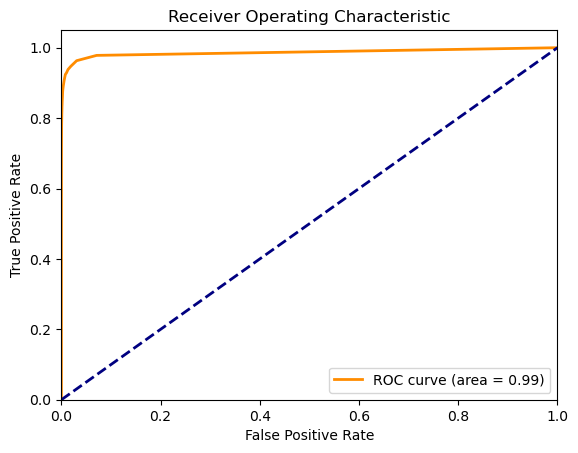

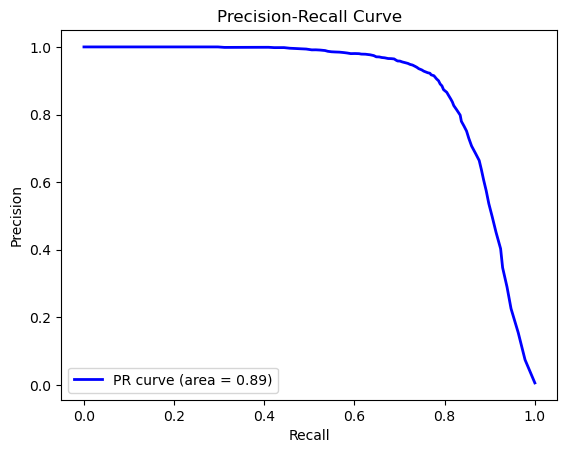

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = rf_model.predict(X_val_scaled_df)
y_val_pred_proba = rf_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


### 7.1.2 cross validation scores

In [74]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(rf_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 1.0000 ± 0.0000, Test: 0.9980 ± 0.0000
Precision - Train: 1.0000 ± 0.0000, Test: 0.9651 ± 0.0029
Recall - Train: 0.9997 ± 0.0001, Test: 0.6780 ± 0.0029
F1 - Train: 0.9999 ± 0.0000, Test: 0.7964 ± 0.0027
Roc_auc - Train: 1.0000 ± 0.0000, Test: 0.9863 ± 0.0024


### 7.1.3 evaluate the model on unseen before hyperparameter tunning

Unseen Data Accuracy (Initial): 0.9963560720436048
Unseen Data Classification Report (Initial):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.98      0.06      0.11      2145

    accuracy                           1.00    555719
   macro avg       0.99      0.53      0.55    555719
weighted avg       1.00      1.00      0.99    555719

Unseen Data Confusion Matrix (Initial):
 [[553571      3]
 [  2022    123]]
Unseen Data ROC AUC Score (Initial): 0.9158963260086144
Unseen Data PR AUC Score (Initial): 0.4619741493702833


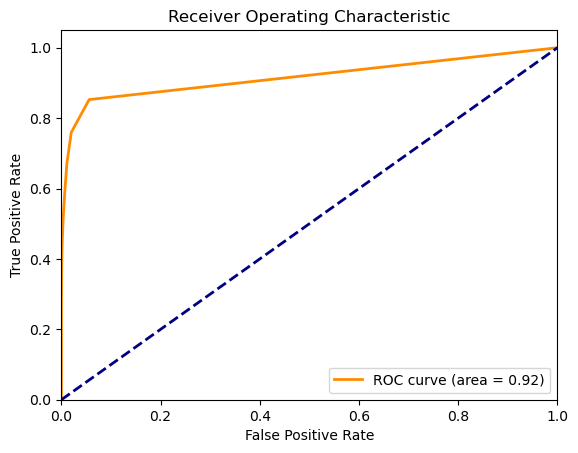

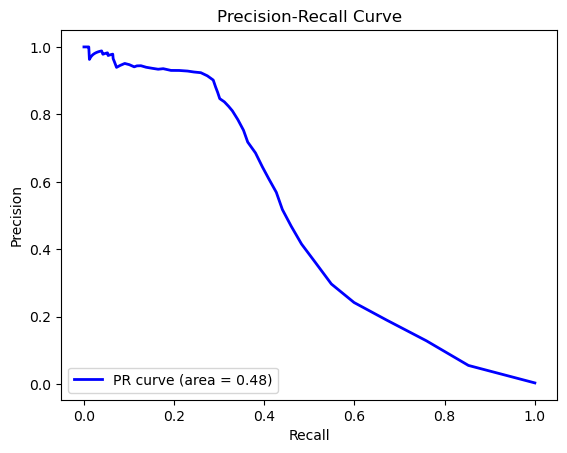

In [76]:
# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train_scaled_df, y_train)
# Make predictions on the unseen data with the initial model (before hyperparameter tuning)
y_unseen_pred_initial = rf_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba_initial = rf_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy (Initial):", accuracy_score(y_unseen, y_unseen_pred_initial))
print("Unseen Data Classification Report (Initial):\n", classification_report(y_unseen, y_unseen_pred_initial))
print("Unseen Data Confusion Matrix (Initial):\n", confusion_matrix(y_unseen, y_unseen_pred_initial))
print("Unseen Data ROC AUC Score (Initial):", roc_auc_score(y_unseen, y_unseen_pred_proba_initial))
print("Unseen Data PR AUC Score (Initial):", average_precision_score(y_unseen, y_unseen_pred_proba_initial))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba_initial)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba_initial)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

### 7.1.4 hyper parameter tunning

In [77]:
%%time
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import joblib

# Ensure the custom cross-validator is defined
strat_k_fold = StratifiedKFold(n_splits=5)

# Define the parameter grid
param_grid = {
    'n_estimators': [10, 20, 40, 50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize the HalvingRandomSearchCV
halving_search = HalvingRandomSearchCV(
    rf_model,
    param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=20,
    verbose=1,  # Add verbosity for debugging
    random_state=42
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    halving_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", halving_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", halving_search.best_score_)


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 10
min_resources_: 20
max_resources_: 907672
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 216
n_resources: 20
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
----------
iter: 1
n_candidates: 72
n_resources: 60
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 2
n_candidates: 24
n_resources: 180
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 3
n_candidates: 8
n_resources: 540
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 4
n_candidates: 3
n_resources: 1620
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best Cross-Validation ROC AUC Score: nan
CPU times: total: 6min 31s
Wall time: 1min 45s


### 7.1.5 Evaluate the Tuned Model on the Unseen Data

Unseen Data Accuracy: 0.996361470455392
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.98      0.06      0.11      2145

    accuracy                           1.00    555719
   macro avg       0.99      0.53      0.55    555719
weighted avg       1.00      1.00      0.99    555719

Unseen Data Confusion Matrix:
 [[553571      3]
 [  2019    126]]
Unseen Data ROC AUC Score: 0.9346374682784991
Unseen Data PR AUC Score: 0.489935735053488


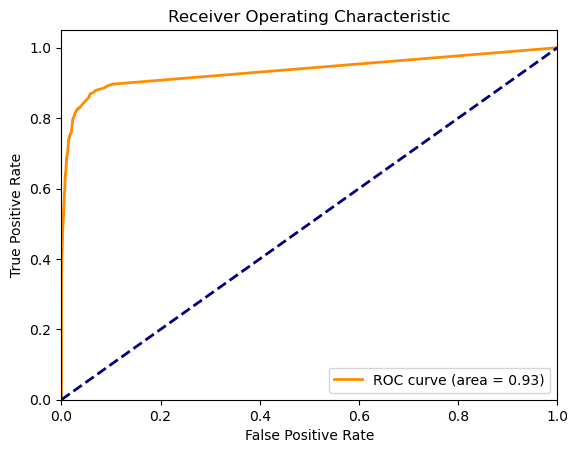

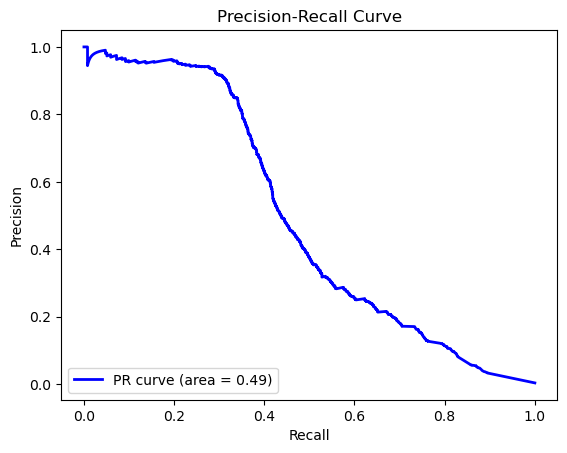

In [78]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = halving_search.best_estimator_.predict(X_unseen_scaled_df)
y_unseen_pred_proba = halving_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [83]:
# checking why would the model perform badly on the unseen compared to the validation
# Compare summary statistics
print(X_train_scaled_df.describe())

                 amt       city_pop     trans_hour    trans_month  \
count  907672.000000  907672.000000  907672.000000  907672.000000   
mean        0.295698       0.272604       0.556690       0.467380   
std         0.276356       0.385677       0.296439       0.310635   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.044961       0.014492       0.304348       0.181818   
50%         0.241648       0.048971       0.608696       0.454545   
75%         0.426899       0.408695       0.826087       0.727273   
max         1.000000       1.000000       1.000000       1.000000   

       timedelta_last_trans       cust_age  distance_from_prev_merch  \
count         907672.000000  907672.000000             907672.000000   
mean               0.298106       0.399221                  0.430804   
std                0.302012       0.213684                  0.239785   
min                0.000000       0.000000                  0.000000   
25%               

In [81]:
print(X_unseen_scaled_df.describe())

                 amt       city_pop     trans_hour    trans_month  \
count  555719.000000  555719.000000  555719.000000  555719.000000   
mean        0.294236       0.265047       0.556916       0.773503   
std         0.274619       0.373685       0.296127       0.179837   
min         0.000000       0.000000       0.000000       0.454545   
25%         0.044857       0.014452       0.304348       0.636364   
50%         0.240608       0.048005       0.608696       0.818182   
75%         0.426275       0.395753       0.826087       1.000000   
max         0.998402       0.967705       1.000000       1.000000   

       timedelta_last_trans       cust_age  distance_from_prev_merch  \
count         555719.000000  555719.000000             555719.000000   
mean               0.250045       0.410107                  0.431227   
std                0.253714       0.214018                  0.239720   
min                0.000000       0.024540                  0.000224   
25%               

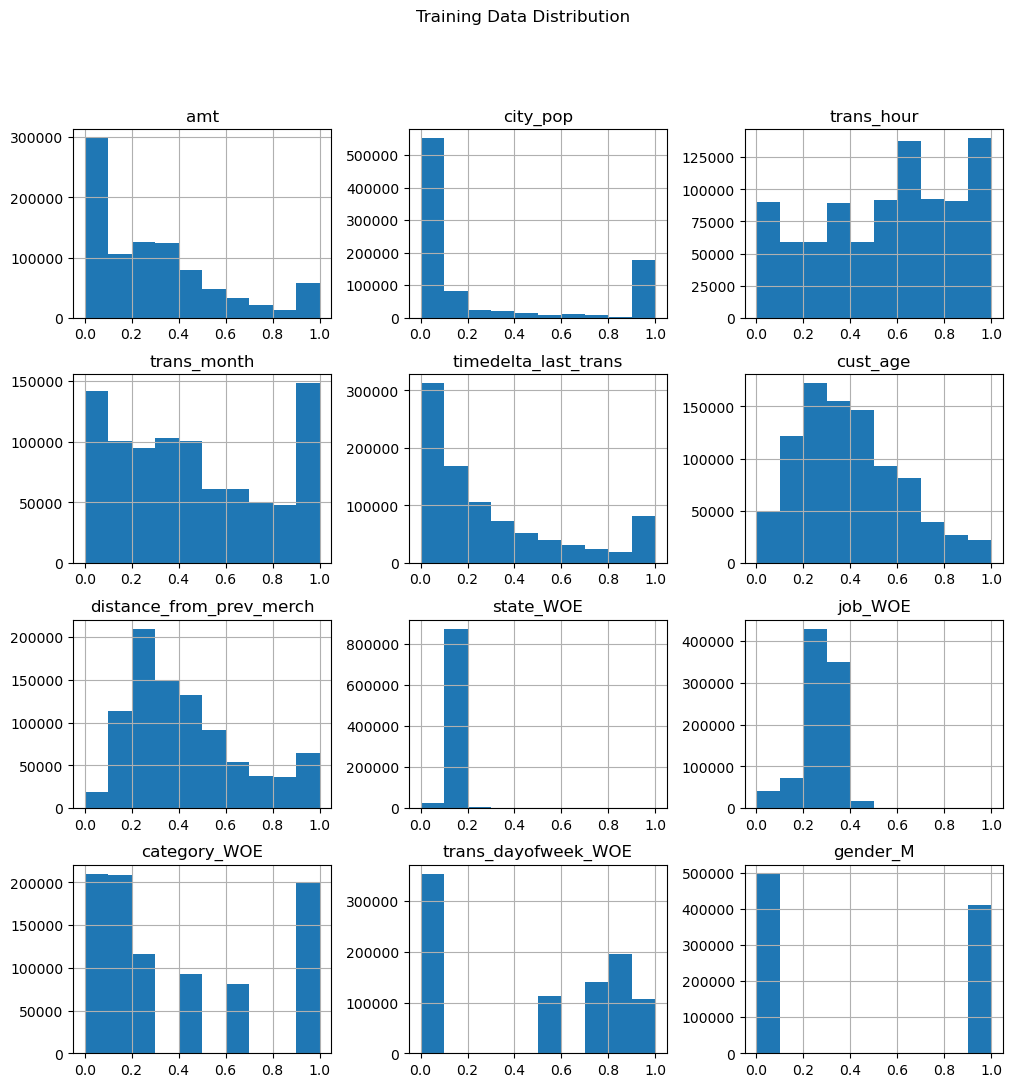

In [82]:
# Visualize distributions
X_train_scaled_df.hist(figsize=(12, 12))
plt.suptitle('Training Data Distribution')
plt.show()

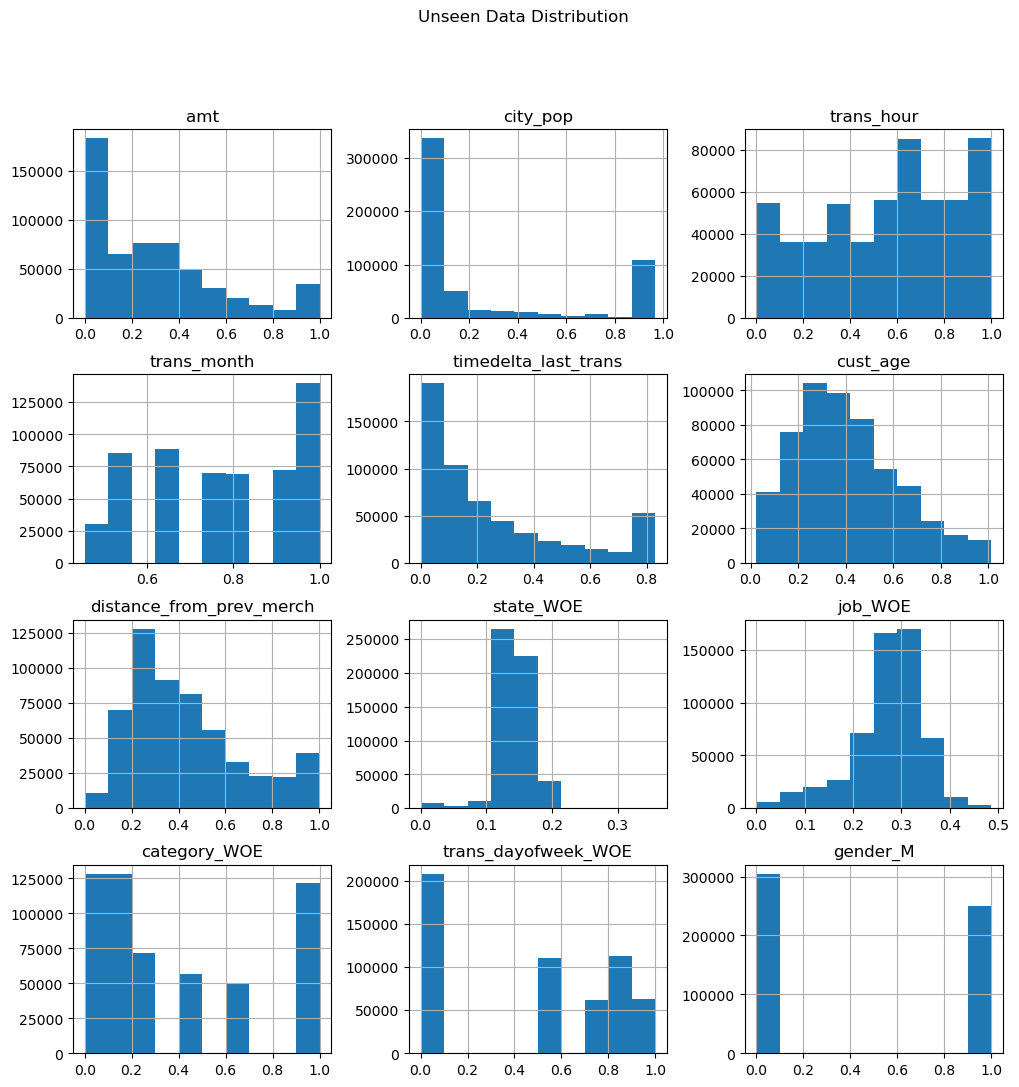

In [84]:
X_unseen_scaled_df.hist(figsize=(12, 12))
plt.suptitle('Unseen Data Distribution')
plt.show()

## 7.2 XGBoost using cost sensitive learning

### 7.2.1 Evaluate initial model on validation set

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9941131559396714
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.50      0.94      0.65      2252

    accuracy                           0.99    389003
   macro avg       0.75      0.97      0.82    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384587   2164]
 [   126   2126]]
Validation ROC AUC Score: 0.9978001304927617
Validation PR AUC Score: 0.9183224209040092


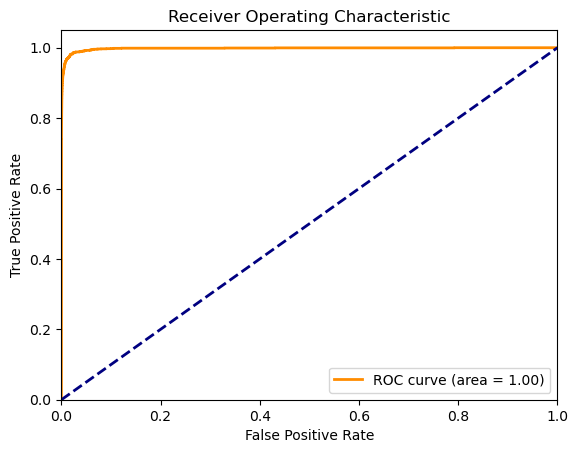

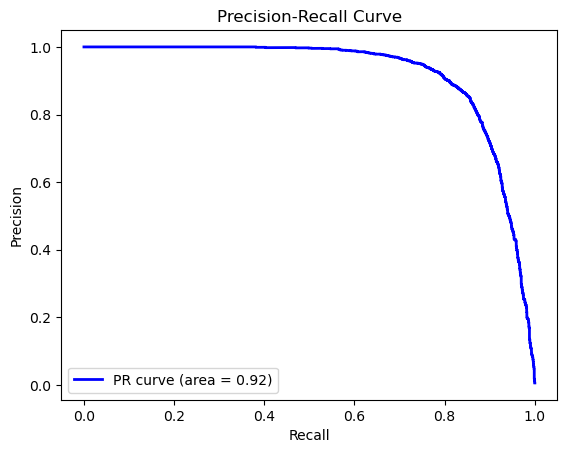

In [85]:
from xgboost import XGBClassifier
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


### 7.2.2 Cross validation

In [86]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9956 ± 0.0002, Test: 0.9946 ± 0.0003
Precision - Train: 0.5665 ± 0.0121, Test: 0.5210 ± 0.0158
Recall - Train: 1.0000 ± 0.0000, Test: 0.9442 ± 0.0078
F1 - Train: 0.7232 ± 0.0099, Test: 0.6714 ± 0.0149
Roc_auc - Train: 0.9999 ± 0.0000, Test: 0.9981 ± 0.0005
CPU times: total: 2min 4s
Wall time: 9.55 s


### 7.2.3 hyperparameter tunning using halving random search cv

In [87]:
%%time
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

# Define the parameter grid
param_grid = {
    'scale_pos_weight': [1, 10, 25, 50, 75, 99, scale_pos_weight,200, 300, 500, 1000],
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the HalvingRandomSearchCV
halving_search = HalvingRandomSearchCV(
    xgb_model,
    param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    refit='roc_auc'
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    halving_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", halving_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", halving_search.best_score_)


Best Parameters: {'scale_pos_weight': 25, 'n_estimators': 200, 'max_depth': None, 'learning_rate': 0.1}
Best Cross-Validation ROC AUC Score: 0.9126841070617099
CPU times: total: 35min 13s
Wall time: 1min 54s


### 7.2.4 tunned model evaluation on unseen data 

Unseen Data Accuracy: 0.9955733023344532
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.45      0.69      0.55      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.84      0.77    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[551785   1789]
 [   671   1474]]
Unseen Data ROC AUC Score: 0.9797708365498761
Unseen Data PR AUC Score: 0.6501301529926784


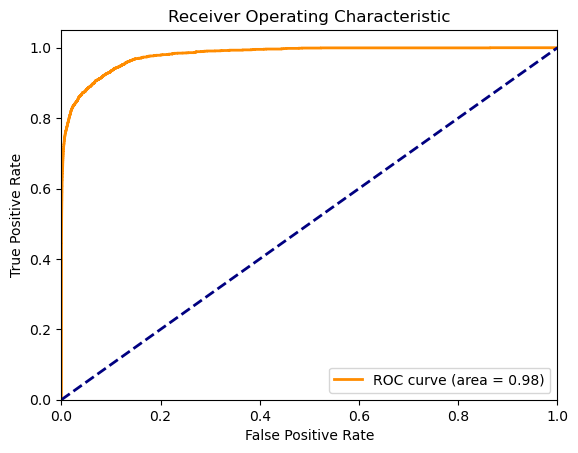

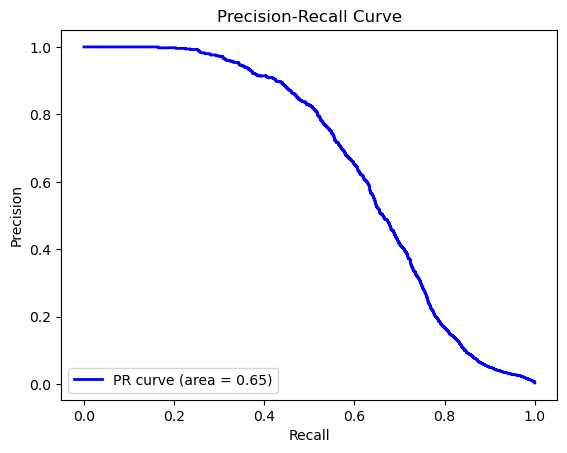

In [88]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = halving_search.best_estimator_.predict(X_unseen_scaled_df)
y_unseen_pred_proba = halving_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


- best model so far based on the cost

### 7.2.5 Threshold tunning

In [89]:
from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Find the threshold that maximizes the F1-score
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))


Best Threshold: 0.8344164
Unseen Data Accuracy (Tuned Threshold): 0.997552719989779
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.75      0.55      0.63      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.77      0.82    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553181    393]
 [   967   1178]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9797708365498761
Unseen Data PR AUC Score (Tuned Threshold): 0.6501301529926784


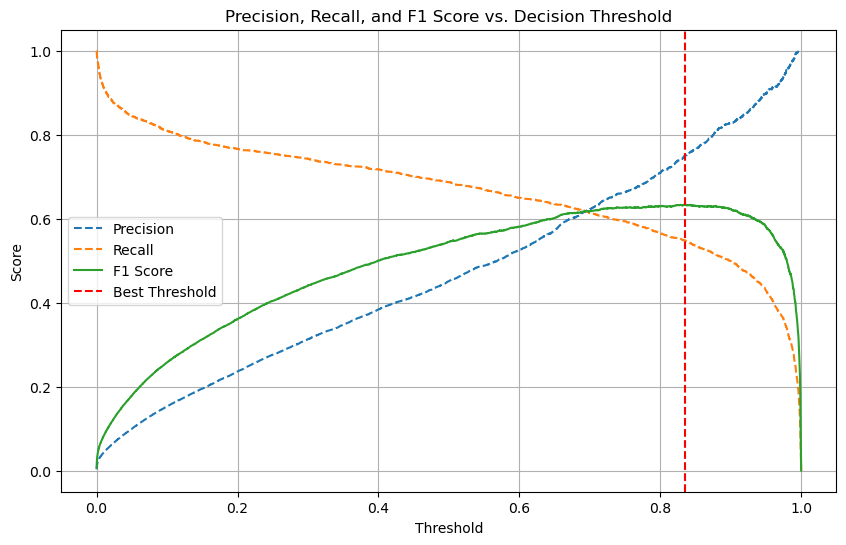

In [90]:
# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='r', linestyle='--', label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

In [91]:
# Save the best model
joblib.dump(halving_search.best_estimator_, 'best_xgb_model.pkl')

# Save the threshold
threshold_file = 'best_threshold.npy'
np.save(threshold_file, best_threshold)

#load the best the model
#best_xgb_model = joblib.load('best_xgb_model.pkl')

# Load the threshold
#best_threshold = np.load('best_threshold.npy')

# Make predictions on new data
#y_new_pred_proba = best_xgb_model.predict_proba(X_new)[:, 1]
#y_new_pred_tuned = (y_new_pred_proba >= best_threshold).astype(int)

## 7.3 XGBoost with Bayesian Optimization

### 7.3.1 Load the Initial Model and Perform Initial Test

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9941131559396714
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.50      0.94      0.65      2252

    accuracy                           0.99    389003
   macro avg       0.75      0.97      0.82    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384587   2164]
 [   126   2126]]
Validation ROC AUC Score: 0.9978001304927617
Validation PR AUC Score: 0.9183224209040092


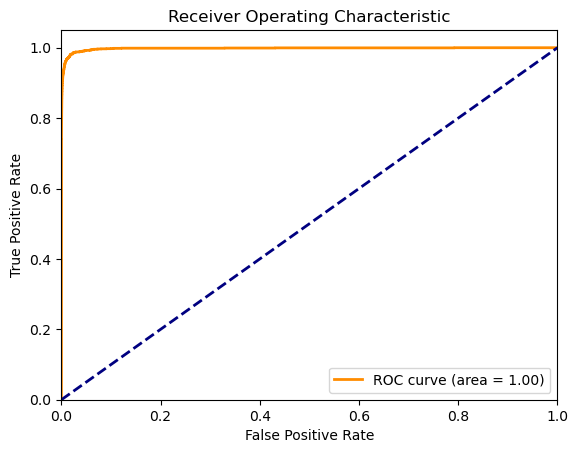

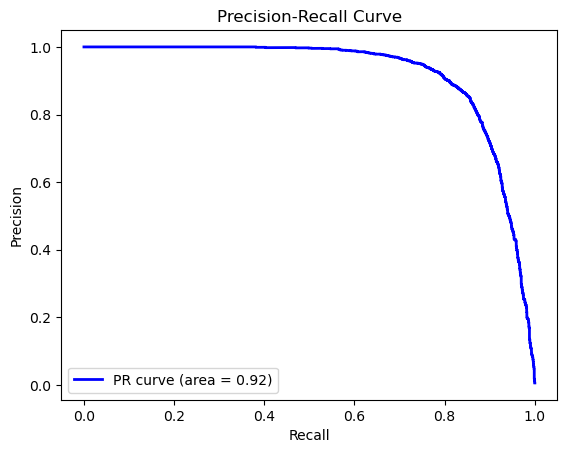

In [92]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

### 7.3.2 Cross-Validation with multiple scoring metrics

In [93]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9956 ± 0.0002, Test: 0.9946 ± 0.0003
Precision - Train: 0.5665 ± 0.0121, Test: 0.5210 ± 0.0158
Recall - Train: 1.0000 ± 0.0000, Test: 0.9442 ± 0.0078
F1 - Train: 0.7232 ± 0.0099, Test: 0.6714 ± 0.0149
Roc_auc - Train: 0.9999 ± 0.0000, Test: 0.9981 ± 0.0005


### 7.3.3 Hyperparameter Tuning using Bayesian Search CV

In [94]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=-1,
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search
bayes_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)

# Save the best model
joblib.dump(bayes_search.best_estimator_, 'best_xgb_model_bayesian.pkl')

Best Parameters: OrderedDict([('learning_rate', 0.12124056477830636), ('max_depth', 29), ('n_estimators', 200), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score: 0.9983292674793024


['best_xgb_model_bayesian.pkl']

### 7.3.4 Load the Best Model and Apply Threshold Tuning and Evaluate the Tuned Model on the Unseen Data

Best Threshold: 0.25005913
Unseen Data Accuracy (Tuned Threshold): 0.9978136432261628
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.79      0.60      0.68      2145

    accuracy                           1.00    555719
   macro avg       0.89      0.80      0.84    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553224    350]
 [   865   1280]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Tuned Threshold): 0.7162845998314531


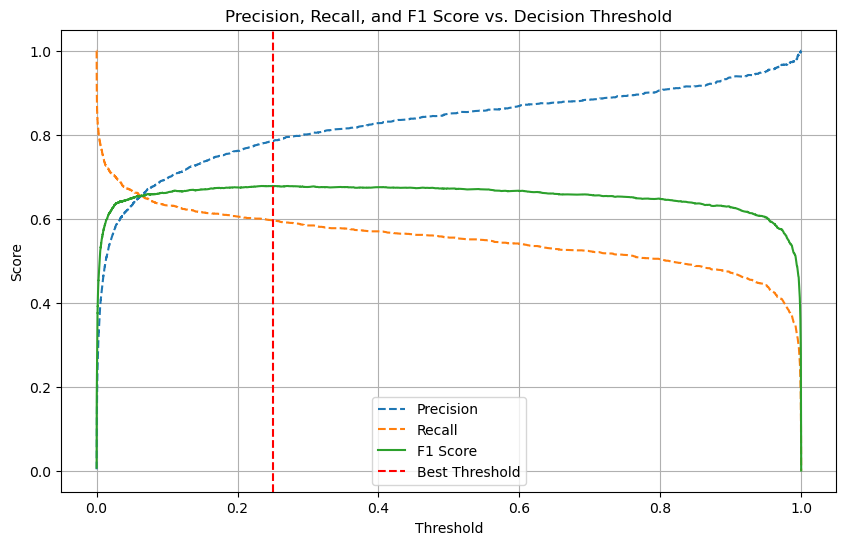

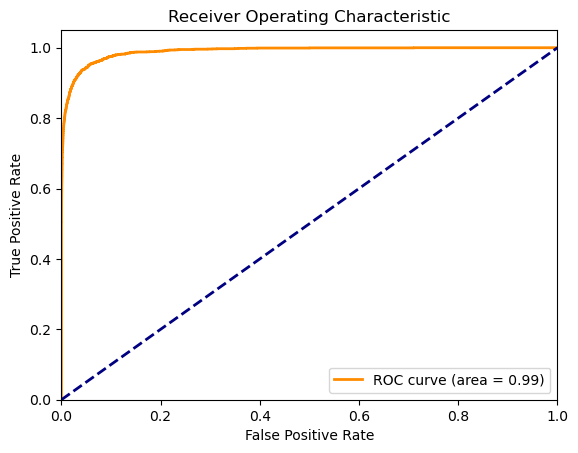

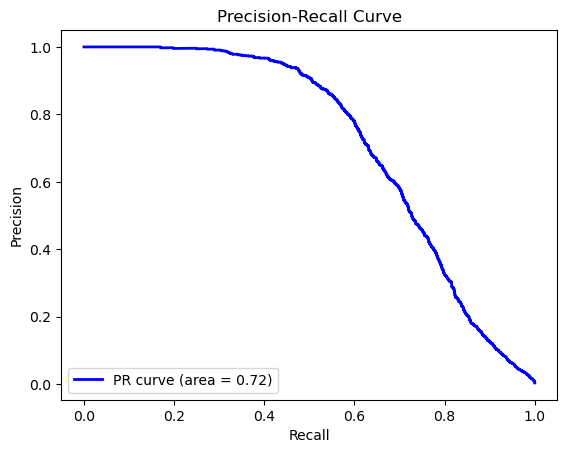

In [97]:
# Load the best model
best_xgb_model = joblib.load('best_xgb_model_bayesian.pkl')

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='r', linestyle='--', label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# Save the threshold
threshold_file = 'best_threshold_bayesian.npy'
np.save(threshold_file, best_threshold)

- best so far ??

### 7.3.5 Evaluating the moden on unseen data using threshold = 0.6

Unseen Data Accuracy (Fixed Threshold): 0.9979072156971419
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.87      0.54      0.67      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.77      0.83    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[553398    176]
 [   987   1158]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Fixed Threshold): 0.7162845998314531


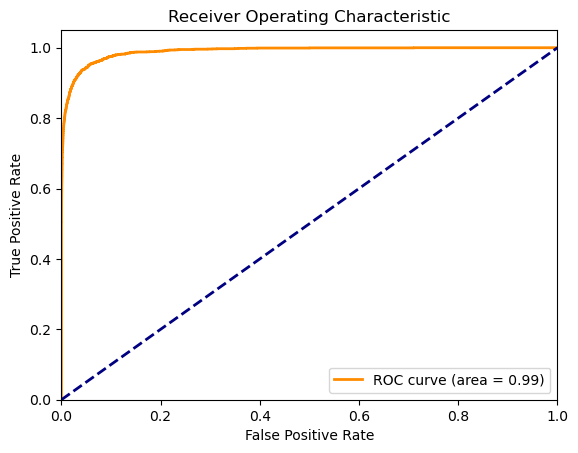

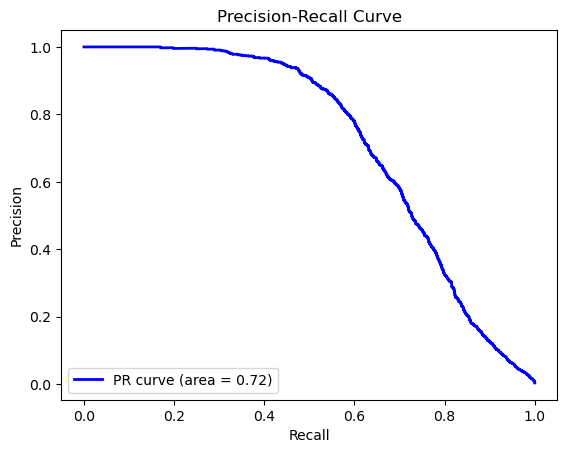

In [98]:
# Load the best model
best_xgb_model = joblib.load('best_xgb_model_bayesian.pkl')

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Apply the fixed threshold of 0.6 to the predictions
fixed_threshold = 0.6
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

### 7.3.6 threshold = 0.1

Unseen Data Accuracy (Fixed Threshold): 0.9975113321660768
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.70      0.63      0.66      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.82      0.83    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
TN: 552981, FP: 593, FN: 790, TP: 1355
[[552981    593]
 [   790   1355]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Fixed Threshold): 0.7162845998314531


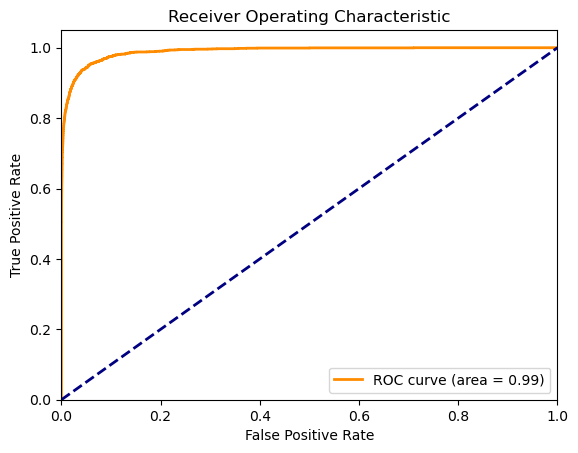

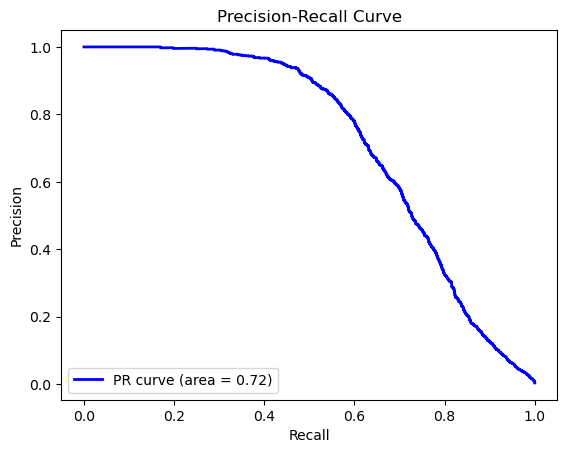

In [105]:
# Load the best model
best_xgb_model = joblib.load('best_xgb_model_bayesian.pkl')

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Apply the fixed threshold of 0.1 to the predictions
fixed_threshold = 0.1
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

## 7.4 xgboost + bayesian optimization + optimize for roc_auc

### 7.4.1  Load the Initial Model and Perform Initial Test

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9941131559396714
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.50      0.94      0.65      2252

    accuracy                           0.99    389003
   macro avg       0.75      0.97      0.82    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384587   2164]
 [   126   2126]]
Validation ROC AUC Score: 0.9978001304927617
Validation PR AUC Score: 0.9183224209040092


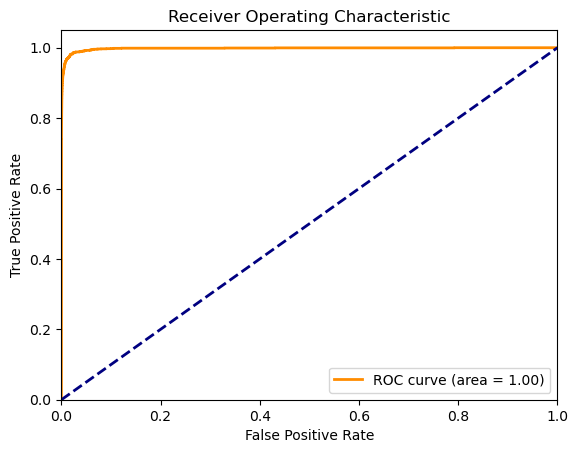

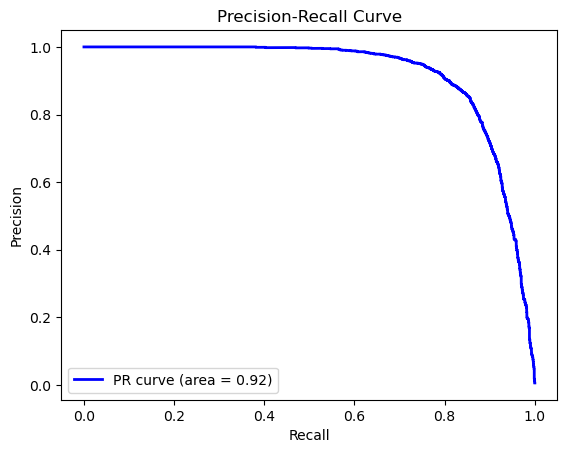

CPU times: total: 21.2 s
Wall time: 2.82 s


In [111]:
%%time
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


### 7.4.2 Cross-Validation with Multiple Scoring Metrics

In [112]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9956 ± 0.0002, Test: 0.9946 ± 0.0003
Precision - Train: 0.5665 ± 0.0121, Test: 0.5210 ± 0.0158
Recall - Train: 1.0000 ± 0.0000, Test: 0.9442 ± 0.0078
F1 - Train: 0.7232 ± 0.0099, Test: 0.6714 ± 0.0149
Roc_auc - Train: 0.9999 ± 0.0000, Test: 0.9981 ± 0.0005
CPU times: total: 2min 10s
Wall time: 12.1 s


### 7.4.3 Hyperparameter Tuning using Bayesian Search CV

In [113]:
%%time
# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',  # Optimize for roc_auc
    n_jobs=-1,
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search
bayes_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)

# Save the best model
joblib.dump(bayes_search.best_estimator_, 'best_xgb_model_bayesian_roc_auc.pkl')

Best Parameters: OrderedDict([('learning_rate', 0.12124056477830636), ('max_depth', 29), ('n_estimators', 200), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score: 0.9983292674793024
CPU times: total: 47.2 s
Wall time: 7min


['best_xgb_model_bayesian_roc_auc.pkl']

### 7.4.4 Load the Best Model and Apply Threshold Tuning

Unseen Data Accuracy (Fixed Threshold): 0.9979072156971419
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.87      0.54      0.67      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.77      0.83    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
TN: 553398, FP: 176, FN: 987, TP: 1158
[[553398    176]
 [   987   1158]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Fixed Threshold): 0.7162845998314531


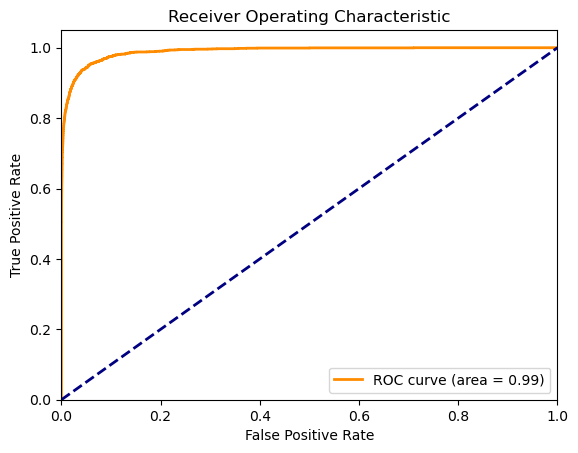

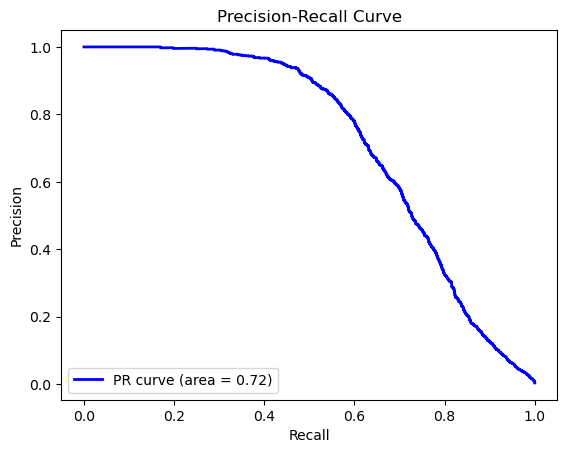

CPU times: total: 10.5 s
Wall time: 1.28 s


In [118]:
%%time
# Load the best model
best_xgb_model = joblib.load('best_xgb_model_bayesian_roc_auc.pkl')

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Apply the fixed threshold of 0.6 to the predictions
fixed_threshold = 0.6
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


### 7.4.5 optimizing for f1-score

Best Threshold: 0.25
Best F1 Score: 0.6781456953642384
Unseen Data Accuracy (Best Threshold): 0.9978136432261628
Unseen Data Classification Report (Best Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.79      0.60      0.68      2145

    accuracy                           1.00    555719
   macro avg       0.89      0.80      0.84    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Best Threshold):
TN: 553224, FP: 350, FN: 865, TP: 1280
[[553224    350]
 [   865   1280]]
Unseen Data ROC AUC Score (Best Threshold): 0.9894060160353375
Unseen Data PR AUC Score (Best Threshold): 0.7162845998314531


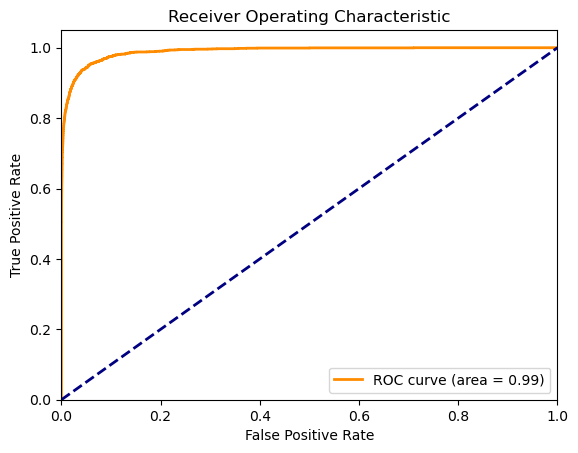

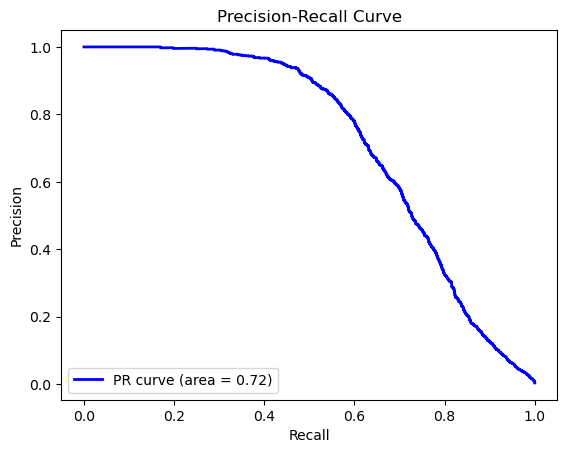

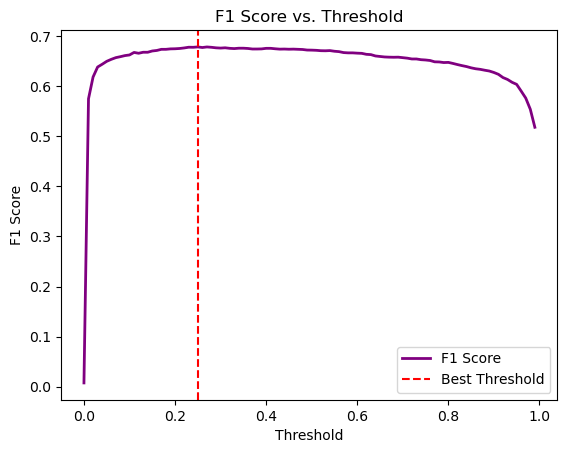

In [115]:
from sklearn.metrics import f1_score

# Function to find the best threshold to optimize F1 score
def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.0, 1.0, 0.01)
    f1_scores = [f1_score(y_true, y_proba >= t) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    best_f1_score = max(f1_scores)
    return best_threshold, best_f1_score, thresholds, f1_scores

# Load the best model
best_xgb_model = joblib.load('best_xgb_model_bayesian.pkl')

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Find the best threshold for the F1 score
best_threshold, best_f1_score, thresholds, f1_scores = find_best_threshold(y_unseen, y_unseen_pred_proba)

print(f"Best Threshold: {best_threshold}")
print(f"Best F1 Score: {best_f1_score}")

# Apply the best threshold to the predictions
y_unseen_pred_best = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the best threshold predictions
print("Unseen Data Accuracy (Best Threshold):", accuracy_score(y_unseen, y_unseen_pred_best))
print("Unseen Data Classification Report (Best Threshold):\n", classification_report(y_unseen, y_unseen_pred_best))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_best)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Best Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Best Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Best Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# Plot F1 Score vs. Threshold
plt.figure()
plt.plot(thresholds, f1_scores, color='purple', lw=2, label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Threshold')
plt.axvline(x=best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.legend(loc="best")
plt.show()


## 7.5 Random forest + smote 

In [119]:
y_val.head()

841190    0
289009    0
500055    0
102808    0
676276    0
Name: is_fraud, dtype: int64

In [121]:
y_train.head()

191915    0
318435    0
212041    0
979109    0
614053    0
Name: is_fraud, dtype: int64

In [122]:
y_unseen.head()

0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

In [123]:
# Save y_val, y_train, and y_unseen to CSV files
#y_val.to_csv('y_val.csv', index=False)
#y_train.to_csv('y_train.csv', index=False)
#y_unseen.to_csv('y_unseen.csv', index=False)